In [ ]:
# Multi-Month Budget App (Week 1–2 only)
# Concepts used: variables, input/output, numeric types, math, strings (format/split/join/slice),
# lists/tuples/sets/dicts, if/else, while/for, range(), break/continue, loop-else, list nesting, nested loops,
# membership & identity operators.

print("=" * 60)
print("💸 WELCOME TO YOUR PERSONAL MONTHLY BUDGET APP (Multi-Month) 💸")
print("=" * 60)

# -------------------------------
# 0) User intro
# -------------------------------
user_name = input("\nWhat is your name? ").strip().title()
user_goal = input("What is your main financial goal (travel, debt, emergency, savings, if no goal is entered: automatically assumed as savings)? ").strip().lower()

print("\nHello,", user_name + "! We'll track multiple months and analyze trends.")
print("Goal noted:", user_goal.title())
print("-" * 60)

# -------------------------------
# 1) Static references
# -------------------------------
months_names = ("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec")

spending_categories = [
    "Housing", "Utilities", "Groceries", "Dining", "Transportation",
    "Insurance", "Debt Payments", "Health", "Entertainment",
    "Subscriptions", "Personal", "Education", "Gifts/Charity", "Misc"
]

recommended_rule = {"Needs": 0.50, "Wants": 0.30, "Savings": 0.20}

needs_set = {"Housing","Utilities","Groceries","Transportation","Insurance","Debt Payments","Health"}
wants_set = {"Dining","Entertainment","Subscriptions","Personal","Education","Gifts/Charity","Misc"}

# -------------------------------
# 2) Storage for multiple months
# -------------------------------
all_months = []   # list of dicts; each dict holds one month’s results

# -------------------------------
# 3) Input loop for months
# -------------------------------
while True:
    raw = input("\nEnter month (1-12, for eample, 8 - August) or 'done' to finish: ").strip().lower()
    if raw == "done":
        break

    # Validate month index
    if not raw.isdigit():
        print("Please enter a number 1–12 or 'done'.")
        continue
    m = int(raw)
    if not (1 <= m <= 12):
        print("Month must be 1–12.")
        continue
    month_index = m - 1

    # --- Income collection ---
    income_sources = []
    print("\nEnter your expected monthly net income sources. Type 'done' when finished.")
    while True:
        s = input("Income amount (or 'done'): ").strip()
        if s.lower() == "done":
            break
        if s == "":
            print("Empty input - try again.")
            continue
        # minimal float check (Week 1–2 friendly)
        ok = True
        dots = 0
        for ch in s:
            if ch == '.':
                dots += 1
                if dots > 1:
                    ok = False
                    break
            elif ch in "+-":
                if s.index(ch) != 0:
                    ok = False
                    break
            elif not ch.isdigit():
                ok = False
                break
        if not ok:
            print("Invalid number format. Try again.")
            continue
        val = float(s)
        if val < 0:
            print("Income cannot be negative.")
            continue
        income_sources.append(val)

    monthly_income = 0.0
    for amt in income_sources:
        monthly_income += amt

    # --- Planned expenses by category ---
    print("\nNow enter PLANNED expenses by category. Type 'skip' to skip a category.")
    planned_expenses = {}
    for cat in spending_categories:
        while True:
            raw_exp = input(f"Planned for {cat}: ").strip()
            if raw_exp.lower() == "skip" or raw_exp == "":
                planned_expenses[cat] = 0.0
                break
            # validate float
            ok = True
            dots = 0
            for ch in raw_exp:
                if ch == '.':
                    dots += 1
                    if dots > 1:
                        ok = False
                        break
                elif ch in "+-":
                    if raw_exp.index(ch) != 0:
                        ok = False
                        break
                elif not ch.isdigit():
                    ok = False
                    break
            if not ok:
                print("Invalid number format. Try again.")
                continue
            val = float(raw_exp)
            if val < 0:
                print("Expense cannot be negative.")
                continue
            planned_expenses[cat] = val
            break

    # --- Aggregations (needs, wants, savings) ---
    total_planned = 0.0
    for k in planned_expenses:
        total_planned += planned_expenses[k]

    needs_total = 0.0
    wants_total = 0.0
    for k in planned_expenses:
        if k in needs_set:
            needs_total += planned_expenses[k]
        elif k in wants_set:
            wants_total += planned_expenses[k]
        else:
            wants_total += planned_expenses[k]  # default

    savings_actual = monthly_income - total_planned
    if savings_actual < 0:
        savings_actual = 0.0

    # --- Ratios (avoid div/0) ---
    denom = monthly_income if monthly_income > 0 else 1.0
    needs_pct = needs_total / denom
    wants_pct = wants_total / denom
    savings_pct = savings_actual / denom

    # --- Store month record ---
    one_month = {
        "month_index": month_index,
        "month_name": months_names[month_index],
        "income": monthly_income,
        "needs_total": needs_total,
        "wants_total": wants_total,
        "savings": savings_actual,
        "needs_pct": needs_pct,
        "wants_pct": wants_pct,
        "savings_pct": savings_pct,
        "planned_expenses": planned_expenses
    }
    all_months.append(one_month)

    # --- Per-month quick summary & advice ---
    print("\n" + "=" * 60)
    print(("📊 SUMMARY for " + months_names[month_index]).center(60))
    print("=" * 60)
    print(f"Total Income:     ${monthly_income:,.2f}")
    print(f"Needs:            ${needs_total:,.2f} ({needs_pct*100:>.1f}%)")
    print(f"Wants:            ${wants_total:,.2f} ({wants_pct*100:>.1f}%)")
    print(f"Savings:          ${savings_actual:,.2f} ({savings_pct*100:>.1f}%)")

    print("\n🎯 PERSONALIZED (Current Month)")
    if user_goal == "travel":
        print("- Create a Travel sub-fund and auto-transfer part of savings.")
    elif user_goal == "debt":
        print("- Prioritize Debt Payments; consider snowball/avalanche.")
    elif user_goal == "emergency":
        print("- Target 3–6 months of Needs in an emergency fund.")
    else:
        print("- Keep savings consistent. Automate transfers each payday.")

    if needs_pct > recommended_rule["Needs"]:
        print("- Needs are above 50% guideline. Review housing/transport/utilities.")
    if wants_pct > recommended_rule["Wants"]:
        print("- Wants exceed 30%. Trim dining/subscriptions/entertainment.")
    if savings_pct < recommended_rule["Savings"]:
        print("- Savings under 20%. Shift 5–10% from Wants to Savings.")
    print("-" * 60)
    print("Month stored. Enter another month or type 'done' to finish.")

# -------------------------------
# 4) End: Month-over-month analysis
# -------------------------------
print("\n" + "=" * 60)
print("📈 MONTH-OVER-MONTH ANALYSIS".center(60))
print("=" * 60)

if len(all_months) == 0:
    print("No months were entered.")
elif len(all_months) == 1:
    m0 = all_months[0]
    print(f"Only one month entered: {m0['month_name']}. See summary above.")
else:
    # Print all months summary
    print("All months snapshot:")
    for i in range(len(all_months)):
        rec = all_months[i]
        print(f" {i+1}. {rec['month_name']}: Income ${rec['income']:,.2f}, "
              f"Needs ${rec['needs_total']:,.2f}, Wants ${rec['wants_total']:,.2f}, "
              f"Savings ${rec['savings']:,.2f}")

    print("\nMoM changes (current vs previous):")
    for i in range(1, len(all_months)):
        prev = all_months[i-1]
        curr = all_months[i]

        # absolute changes
        inc_diff = curr["income"] - prev["income"]
        needs_diff = curr["needs_total"] - prev["needs_total"]
        wants_diff = curr["wants_total"] - prev["wants_total"]
        sav_diff = curr["savings"] - prev["savings"]

        # percentage helpers (avoid div/0)
        def pct_change(new, old):
            denom = old if old != 0 else 1.0
            return (new - old) / denom * 100.0

        inc_pct = pct_change(curr["income"], prev["income"])
        needs_pct_chg = pct_change(curr["needs_total"], prev["needs_total"])
        wants_pct_chg = pct_change(curr["wants_total"], prev["wants_total"])
        sav_pct_chg = pct_change(curr["savings"], prev["savings"])

        print("-" * 60)
        print(f"{prev['month_name']} ➜ {curr['month_name']}")
        print(f" Income:  ${prev['income']:,.2f} ➜ ${curr['income']:,.2f}  ({inc_pct:>.1f}%)")
        print(f" Needs:   ${prev['needs_total']:,.2f} ➜ ${curr['needs_total']:,.2f}  ({needs_pct_chg:>.1f}%)")
        print(f" Wants:   ${prev['wants_total']:,.2f} ➜ ${curr['wants_total']:,.2f}  ({wants_pct_chg:>.1f}%)")
        print(f" Savings: ${prev['savings']:,.2f} ➜ ${curr['savings']:,.2f}  ({sav_pct_chg:>.1f}%)")

        # Tailored MoM advice
        print("\n🧭 MoM Advice:")
        if inc_diff < 0:
            print("- Income decreased. Consider pausing non-essential Wants.")
        if wants_diff > 0 and sav_diff < 0:
            print("- Wants rose while Savings fell. Shift discretionary spend into Savings.")
        if needs_diff > 0 and curr["needs_total"] / (curr["income"] if curr["income"]>0 else 1.0) > 0.5:
            print("- Needs creeping up past 50%. Review housing, insurance, and utilities.")
        if sav_diff > 0:
            print("- Nice! Savings increased. Keep the momentum with auto-transfers.")
        if user_goal == "debt" and curr["planned_expenses"].get("Debt Payments", 0.0) <= prev["planned_expenses"].get("Debt Payments", 0.0):
            print("- Goal is debt, but payments didn’t rise. Consider reallocating Wants to debt.")
        if user_goal == "travel" and sav_diff <= 0:
            print("- Travel goal: earmark a fixed amount to a Travel fund each month.")
        if user_goal == "emergency" and curr["savings"] < (0.2 * (curr["income"] if curr["income"]>0 else 1.0)):
            print("- Emergency goal: aim for 20% savings; trim Wants by 5–10% to boost cushion.")

# -------------------------------
# 5) Closing
# -------------------------------
print("\n" + "=" * 60)
print(f"Done. Thanks for budgeting with us, {user_name}! 🚀")



💸 WELCOME TO YOUR PERSONAL MONTHLY BUDGET APP (Multi-Month) 💸


KeyboardInterrupt: Interrupted by user

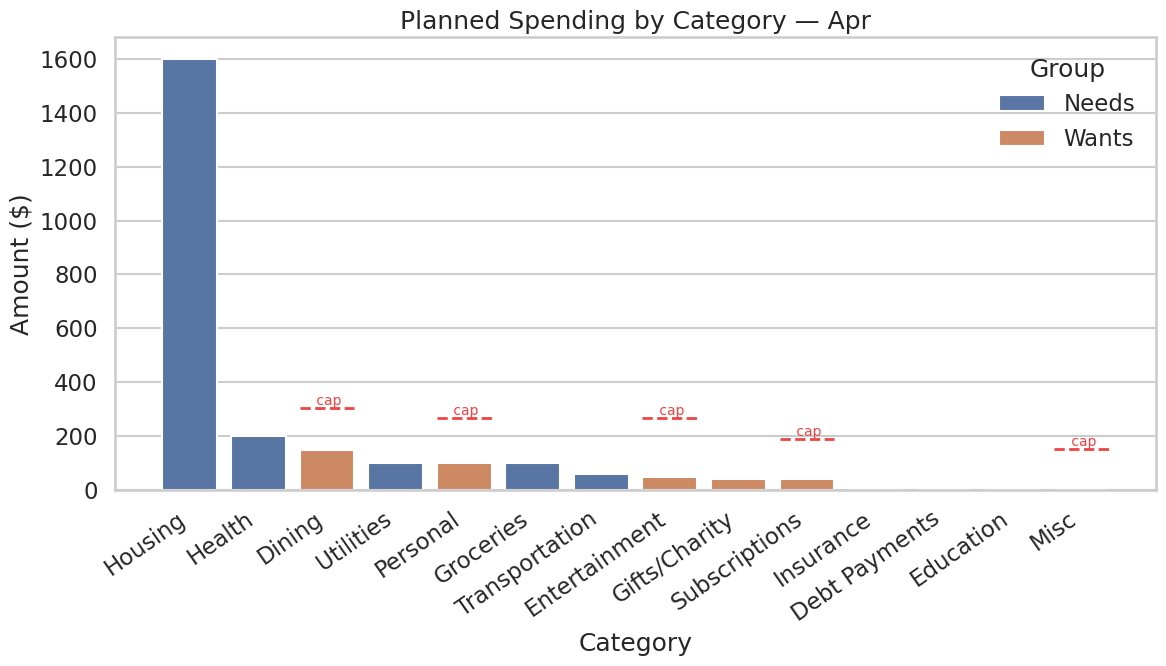

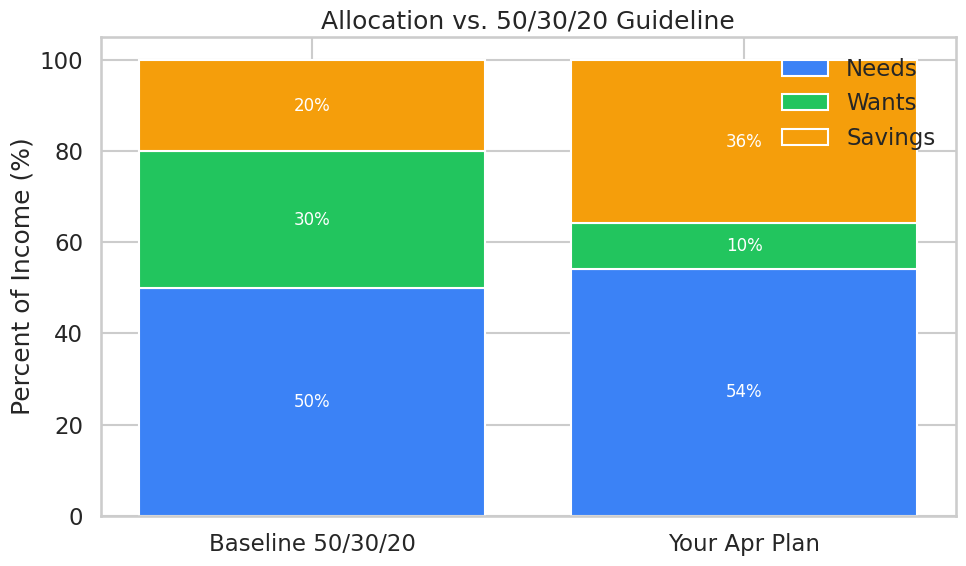

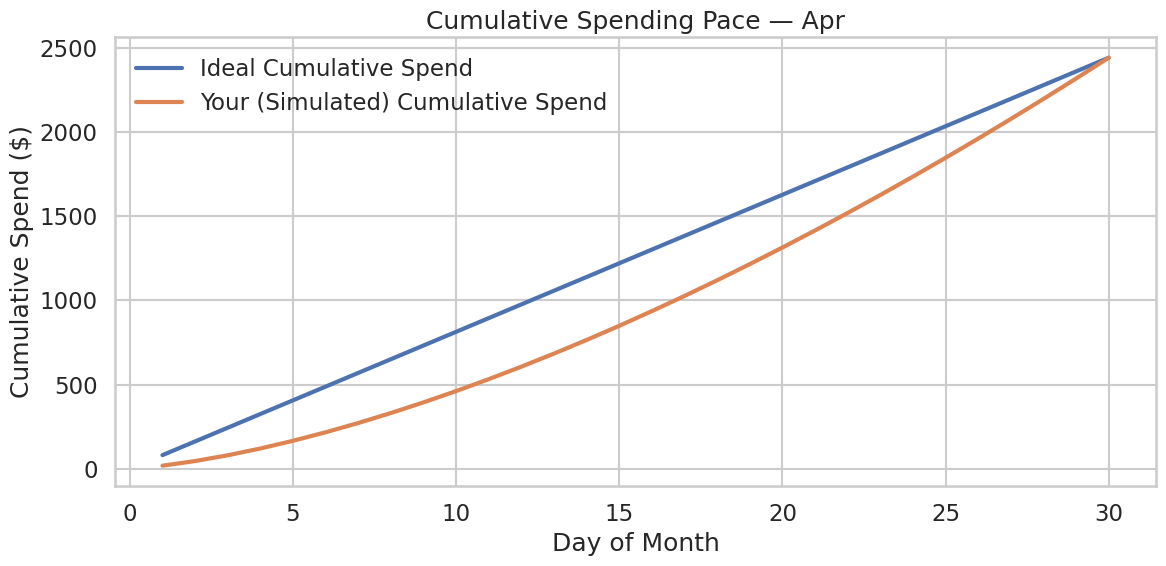

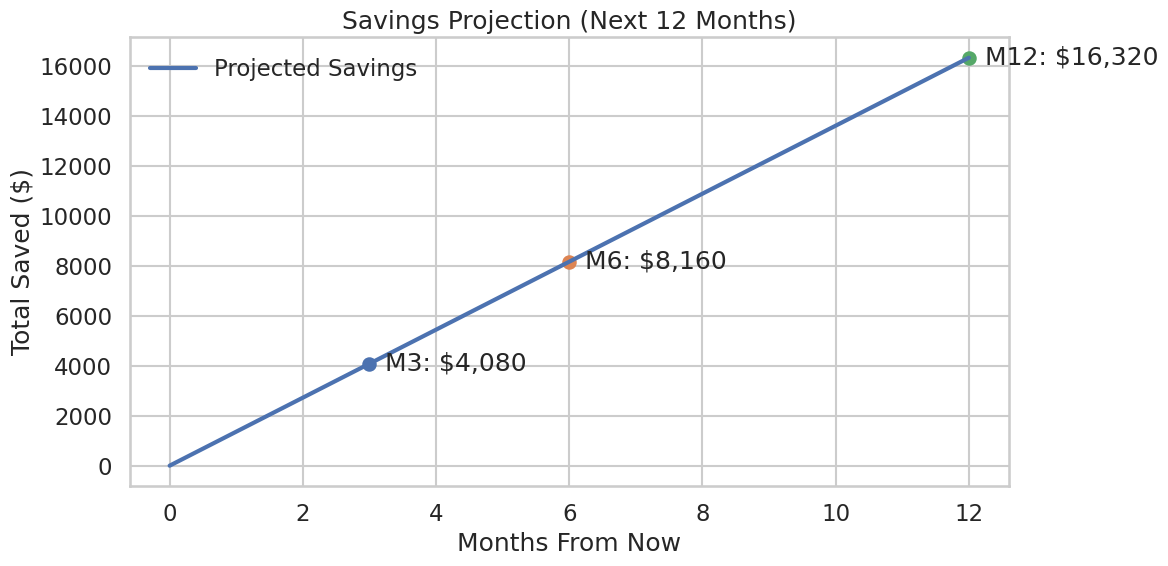

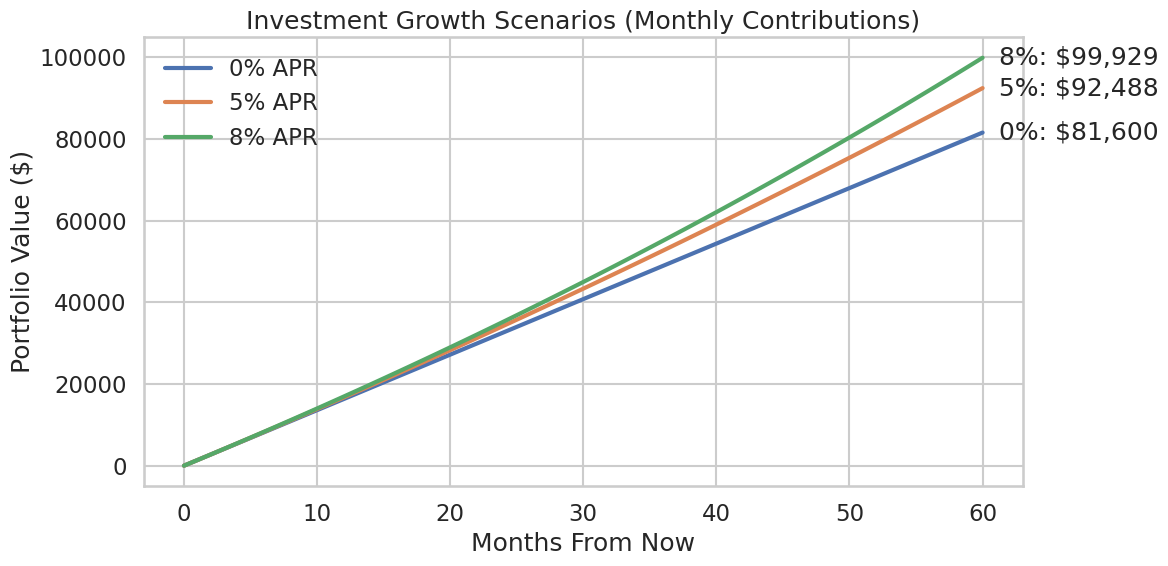

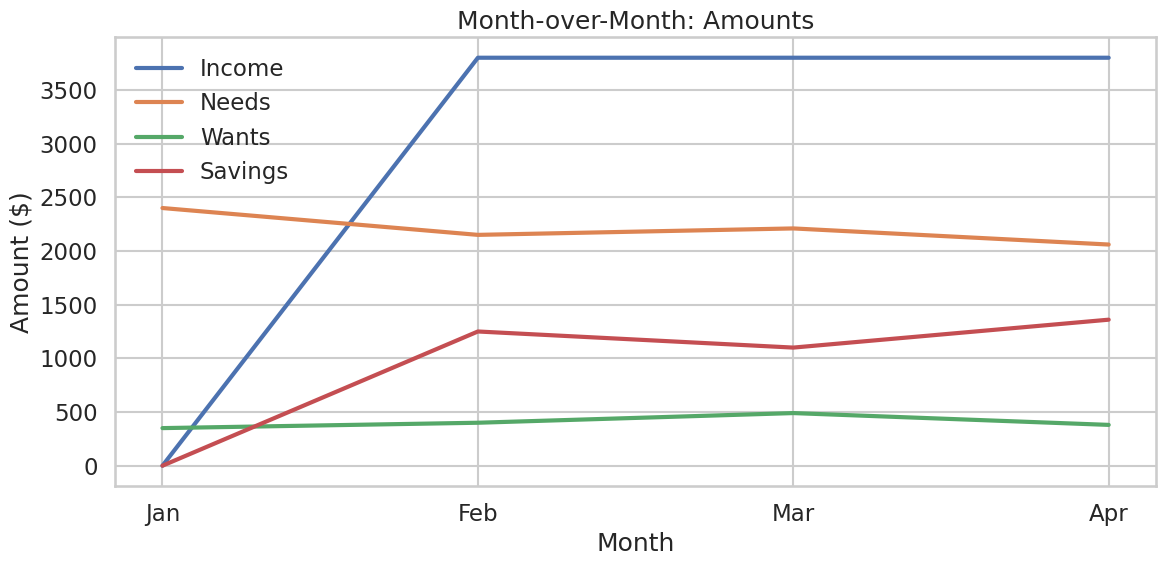

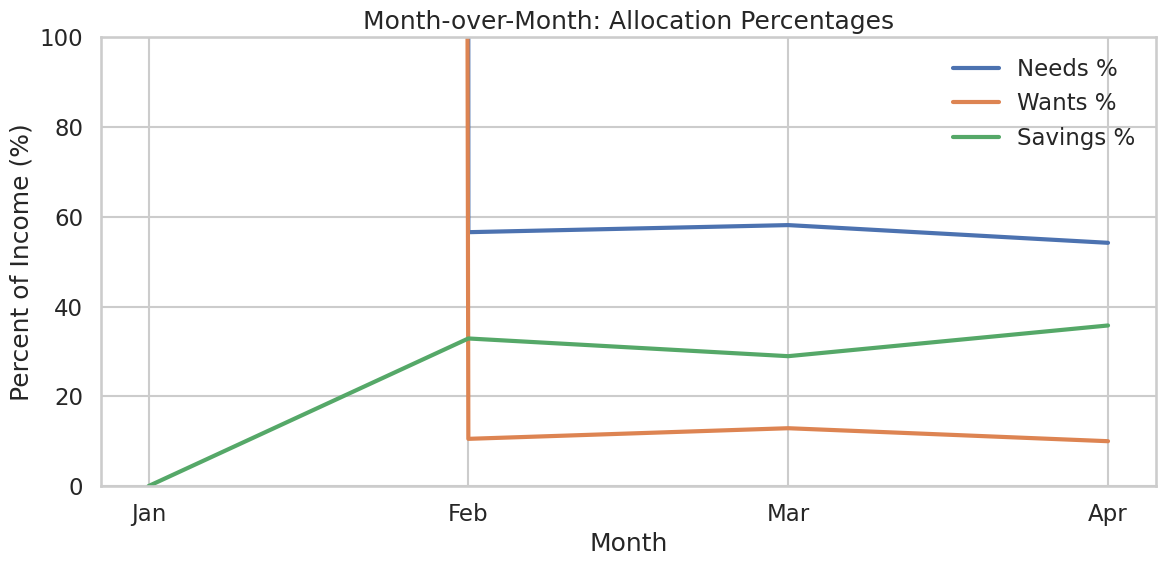

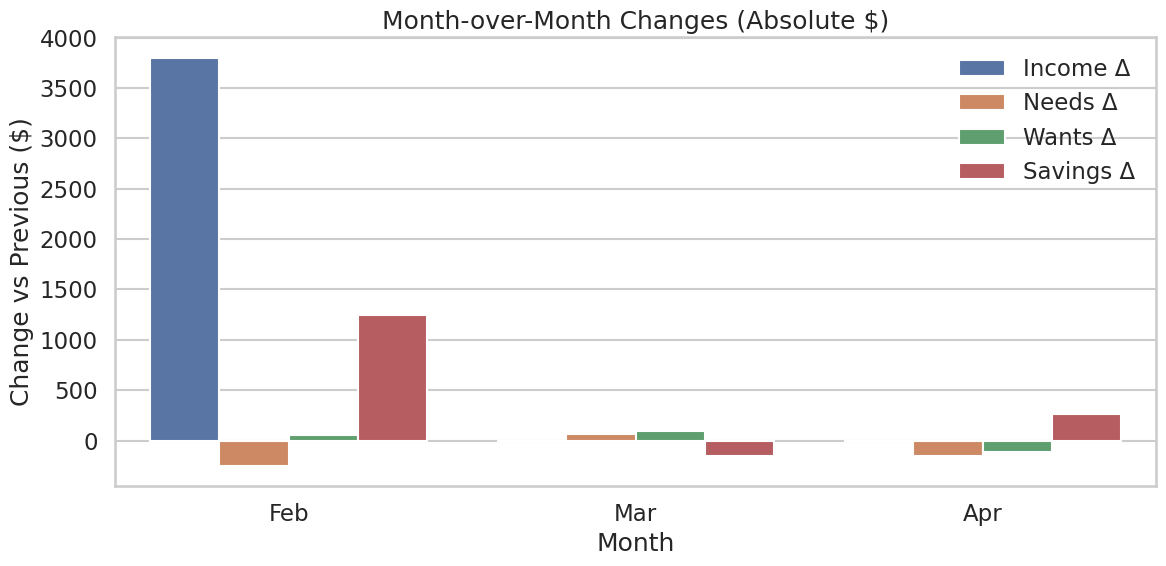


=== ACTIONABLE GUIDANCE (Current Month) ===
- Your savings rate meets or exceeds the 20% guideline. Great job!
- Needs are 54.2% of income (over 50%). Review housing/insurance/transport.
- Automate investing right after payday to stay consistent.


In [ ]:
# === VISUALS ADD-ON ===
# Requires: pandas, numpy, matplotlib, seaborn
# If needed: pip install pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Guard: need at least 1 month to visualize
if len(all_months) == 0:
    print("\n[VISUALS] No months entered — skipping charts.")
else:
    # ------------------------------------------------------------
    # Pull the CURRENT (last-entered) month record from all_months
    # ------------------------------------------------------------
    curr = all_months[-1]
    month_label = curr["month_name"]
    monthly_income = curr["income"]
    needs_total = curr["needs_total"]
    wants_total = curr["wants_total"]
    savings_actual = curr["savings"]
    needs_pct = curr["needs_pct"]
    wants_pct = curr["wants_pct"]
    savings_pct = curr["savings_pct"]
    planned_expenses = curr["planned_expenses"]  # dict: category -> amount

    # Category grouping helper uses your sets from the app
    def cat_group(c_name):
        if c_name in needs_set:
            return "Needs"
        elif c_name in wants_set:
            return "Wants"
        return "Wants"  # default to Wants if unknown

    # --------- Build tidy data for CURRENT month ---------
    cat_df = pd.DataFrame(
        [{"category": k, "amount": float(v)} for k, v in planned_expenses.items()]
    )
    if cat_df.empty:
        cat_df = pd.DataFrame([{"category": "(none)", "amount": 0.0}])

    cat_df["group"] = cat_df["category"].apply(cat_group)

    income_safe = monthly_income if monthly_income > 0 else 1.0
    cat_df["share_of_income"] = cat_df["amount"] / income_safe

    # Optional soft caps like your app
    soft_caps = {
        "Dining": 0.08, "Entertainment": 0.07, "Subscriptions": 0.05,
        "Personal": 0.07, "Misc": 0.04
    }
    cat_df["soft_cap"] = cat_df["category"].map(soft_caps).astype(float)

    # --------- 1) Category bar chart with soft-cap markers (CURRENT MONTH) ---------
    plt.figure(figsize=(12, 7))
    order = cat_df.sort_values("amount", ascending=False)["category"]
    ax = sns.barplot(data=cat_df, x="category", y="amount", hue="group", order=order)
    ax.set_title(f"Planned Spending by Category — {month_label}")
    ax.set_xlabel("Category")
    ax.set_ylabel("Amount ($)")
    plt.xticks(rotation=35, ha="right")

    # Soft-cap horizontal markers (as $ based on % of income)
    for i, row in cat_df.set_index("category").loc[order].reset_index().iterrows():
        cap = row["soft_cap"]
        if not pd.isna(cap):
            cap_value = cap * income_safe
            ax.plot([i-0.4, i+0.4], [cap_value, cap_value], linestyle="--", linewidth=2, color="#ef4444")
            ax.text(i, cap_value, " cap", va="bottom", ha="center", fontsize=10, color="#ef4444")

    plt.legend(title="Group", frameon=False)
    plt.tight_layout()
    plt.show()

    # --------- 2) Stacked bars: 50/30/20 baseline vs Your plan (CURRENT MONTH) ---------
    baseline = pd.DataFrame({
        "label": ["Baseline 50/30/20"],
        "Needs": [recommended_rule["Needs"]],
        "Wants": [recommended_rule["Wants"]],
        "Savings": [recommended_rule["Savings"]],
    })
    actual = pd.DataFrame({
        "label": [f"Your {month_label} Plan"],
        "Needs": [needs_pct],
        "Wants": [wants_pct],
        "Savings": [savings_pct],
    })
    compare = pd.concat([baseline, actual], ignore_index=True)

    plt.figure(figsize=(10, 6))
    bottom = np.zeros(len(compare))
    for col, color in zip(["Needs", "Wants", "Savings"], ["#3b82f6", "#22c55e", "#f59e0b"]):
        vals = compare[col].values * 100
        plt.bar(compare["label"], vals, bottom=bottom * 100, label=col, color=color)
        # label inside segment if big enough
        for i, v in enumerate(vals):
            if v > 8:
                plt.text(i, bottom[i]*100 + v/2, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=12)
        bottom += compare[col].values

    plt.title("Allocation vs. 50/30/20 Guideline")
    plt.ylabel("Percent of Income (%)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # --------- 3) Cumulative spending vs ideal pace (CURRENT MONTH, simulated) ---------
    month_length = 30  # simple display
    total_budget_to_spend = needs_total + wants_total  # all planned (no extras dict here)
    ideal_daily = total_budget_to_spend / month_length
    days = np.arange(1, month_length + 1)
    ideal_line = ideal_daily * days

    # Simulated "front-loaded" spend curve to visualize overspending risk
    front_load_factor = 1.8
    weights = np.array([(month_length - d + 1) for d in days])**(1/front_load_factor)
    weights = weights[::-1]
    weights = weights / weights.sum()
    pseudo_spend = total_budget_to_spend * weights
    cumulative_pseudo = np.cumsum(pseudo_spend)

    plt.figure(figsize=(12, 6))
    plt.plot(days, ideal_line, linewidth=3, label="Ideal Cumulative Spend")
    plt.plot(days, cumulative_pseudo, linewidth=3, label="Your (Simulated) Cumulative Spend")
    plt.title(f"Cumulative Spending Pace — {month_label}")
    plt.xlabel("Day of Month")
    plt.ylabel("Cumulative Spend ($)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # --------- 4) Savings trajectory vs. emergency fund (simple default) ---------
    # If user goal is emergency and no explicit target, default to 3 months of Needs
    if user_goal == "emergency":
        goal_emergency_months = 3.0
    else:
        goal_emergency_months = 0.0  # no line shown

    monthly_core_needs = needs_total
    target_emergency_total = goal_emergency_months * monthly_core_needs
    months_ahead = 12
    t = np.arange(0, months_ahead + 1)
    savings_monthly = max(savings_actual, 0.0)
    proj_savings = savings_monthly * t

    plt.figure(figsize=(12, 6))
    plt.plot(t, proj_savings, linewidth=3, label="Projected Savings")
    if goal_emergency_months > 0:
        plt.axhline(target_emergency_total, linestyle="--", linewidth=2,
                    label=f"Emergency Goal (${target_emergency_total:,.0f})")
    plt.title("Savings Projection (Next 12 Months)")
    plt.xlabel("Months From Now")
    plt.ylabel("Total Saved ($)")
    for i in [3, 6, 12]:
        if i <= months_ahead:
            plt.scatter([i], [proj_savings[i]], s=80)
            plt.text(i, proj_savings[i], f"  M{i}: ${proj_savings[i]:,.0f}", va="center")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # --------- 5) Investment growth scenarios (monthly compounding) ---------
    def future_values(months, contrib, apr):
        r = apr / 12.0
        values = []
        total = 0.0
        for _ in range(months + 1):
            values.append(total)
            total = total * (1 + r) + contrib
        return np.array(values)

    horizon = 60  # 5 years
    fv_0 = future_values(horizon, savings_monthly, 0.00)
    fv_5 = future_values(horizon, savings_monthly, 0.05)
    fv_8 = future_values(horizon, savings_monthly, 0.08)

    plt.figure(figsize=(12, 6))
    xh = np.arange(horizon + 1)
    plt.plot(xh, fv_0, linewidth=3, label="0% APR")
    plt.plot(xh, fv_5, linewidth=3, label="5% APR")
    plt.plot(xh, fv_8, linewidth=3, label="8% APR")
    plt.title("Investment Growth Scenarios (Monthly Contributions)")
    plt.xlabel("Months From Now")
    plt.ylabel("Portfolio Value ($)")
    for label, val in [("0%", fv_0[-1]), ("5%", fv_5[-1]), ("8%", fv_8[-1])]:
        plt.text(horizon, val, f"  {label}: ${val:,.0f}", va="center")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # MONTH-OVER-MONTH VISUALS (requires >= 2 months)
    # ------------------------------------------------------------
    if len(all_months) >= 2:
        # Build MoM DataFrame from all_months
        mom_df = pd.DataFrame([{
            "Month": rec["month_name"],
            "Income": rec["income"],
            "Needs": rec["needs_total"],
            "Wants": rec["wants_total"],
            "Savings": rec["savings"],
            "Needs %": rec["needs_pct"] * 100.0,
            "Wants %": rec["wants_pct"] * 100.0,
            "Savings %": rec["savings_pct"] * 100.0,
        } for rec in all_months])

        # Line plots over time (Income / Needs / Wants / Savings)
        plt.figure(figsize=(12, 6))
        for col in ["Income", "Needs", "Wants", "Savings"]:
            plt.plot(mom_df["Month"], mom_df[col], linewidth=3, label=col)
        plt.title("Month-over-Month: Amounts")
        plt.xlabel("Month")
        plt.ylabel("Amount ($)")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

        # Percentage trends (lines)
        plt.figure(figsize=(12, 6))
        for col in ["Needs %", "Wants %", "Savings %"]:
            plt.plot(mom_df["Month"], mom_df[col], linewidth=3, label=col)
        plt.title("Month-over-Month: Allocation Percentages")
        plt.xlabel("Month")
        plt.ylabel("Percent of Income (%)")
        plt.ylim(0, 100)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

        # Bar chart of MoM deltas for each metric vs previous month
        mom_delta = mom_df.copy()
        mom_delta[["Income Δ", "Needs Δ", "Wants Δ", "Savings Δ"]] = mom_delta[
            ["Income", "Needs", "Wants", "Savings"]
        ].diff()
        mom_delta = mom_delta.iloc[1:]  # first row has no delta

        # Melt to long format for grouped bar chart
        delta_long = mom_delta.melt(
            id_vars="Month",
            value_vars=["Income Δ", "Needs Δ", "Wants Δ", "Savings Δ"],
            var_name="Metric",
            value_name="Change"
        )

        plt.figure(figsize=(12, 6))
        ax = sns.barplot(data=delta_long, x="Month", y="Change", hue="Metric")
        ax.set_title("Month-over-Month Changes (Absolute $)")
        ax.set_xlabel("Month")
        ax.set_ylabel("Change vs Previous ($)")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    # --------- 6) Actionable text guidance (prints; CURRENT MONTH) ---------
    print("\n=== ACTIONABLE GUIDANCE (Current Month) ===")
    target_savings_pct = recommended_rule["Savings"]
    if savings_pct < target_savings_pct:
        gap = (target_savings_pct - savings_pct) * monthly_income
        print(f"- Increase savings by about ${gap:,.0f}/mo to hit {int(target_savings_pct*100)}% of income.")
    else:
        print("- Your savings rate meets or exceeds the 20% guideline. Great job!")

    if needs_pct > recommended_rule["Needs"]:
        print(f"- Needs are {needs_pct*100:.1f}% of income (over 50%). Review housing/insurance/transport.")
    if wants_pct > recommended_rule["Wants"]:
        top_wants = (cat_df[cat_df["group"] == "Wants"]
                     .sort_values("amount", ascending=False)
                     .head(3)["category"].tolist())
        if top_wants:
            print(f"- Wants are {wants_pct*100:.1f}% (over 30%). Trim top categories: {', '.join(top_wants)}.")

    if user_goal == "emergency":
        if goal_emergency_months > 0 and target_emergency_total > 0:
            months_to_goal = int(np.ceil(max(0.0, target_emergency_total) / max(1.0, savings_monthly)))
            print(f"- At ${savings_monthly:,.0f}/mo, you’d reach your emergency goal (~${target_emergency_total:,.0f}) in ~{months_to_goal} months.")
        else:
            print("- Set an emergency goal (e.g., 3 months of core needs).")

    if savings_monthly > 0:
        print("- Automate investing right after payday to stay consistent.")
    else:
        print("- Start with a small automatic transfer (e.g., $50–$100) to build the habit.")


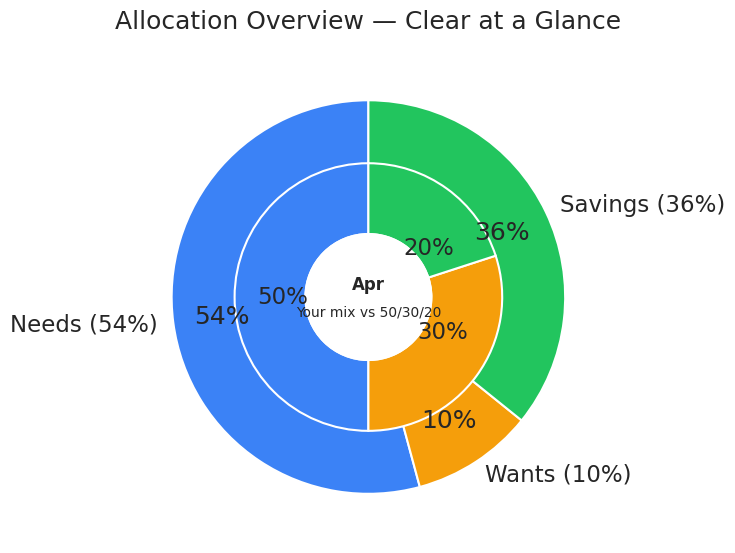

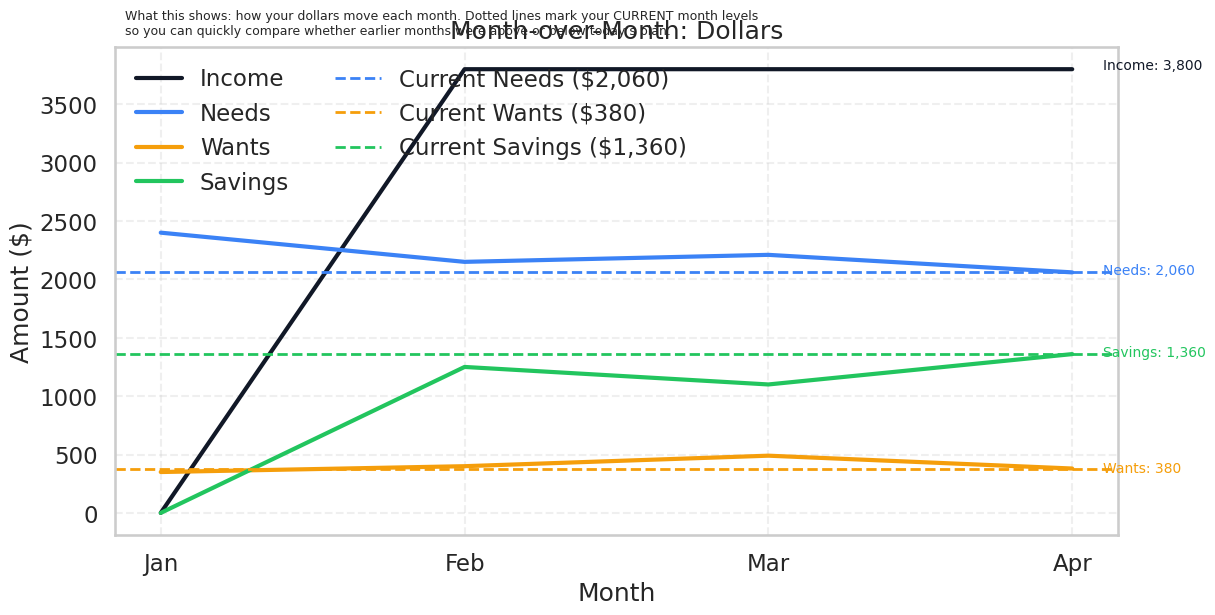

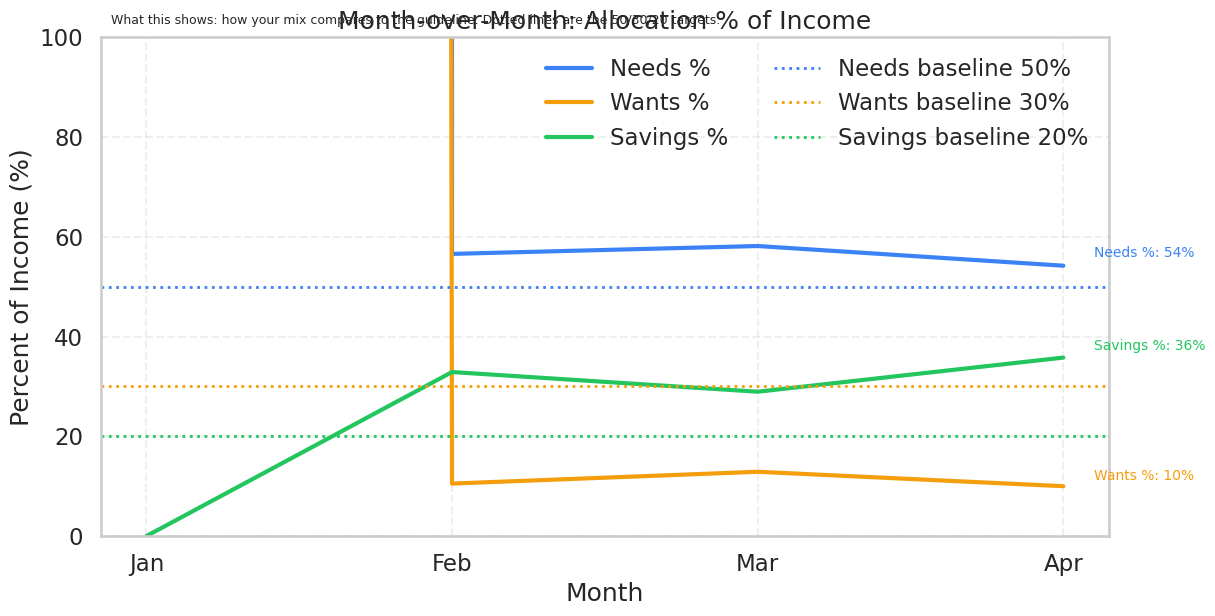

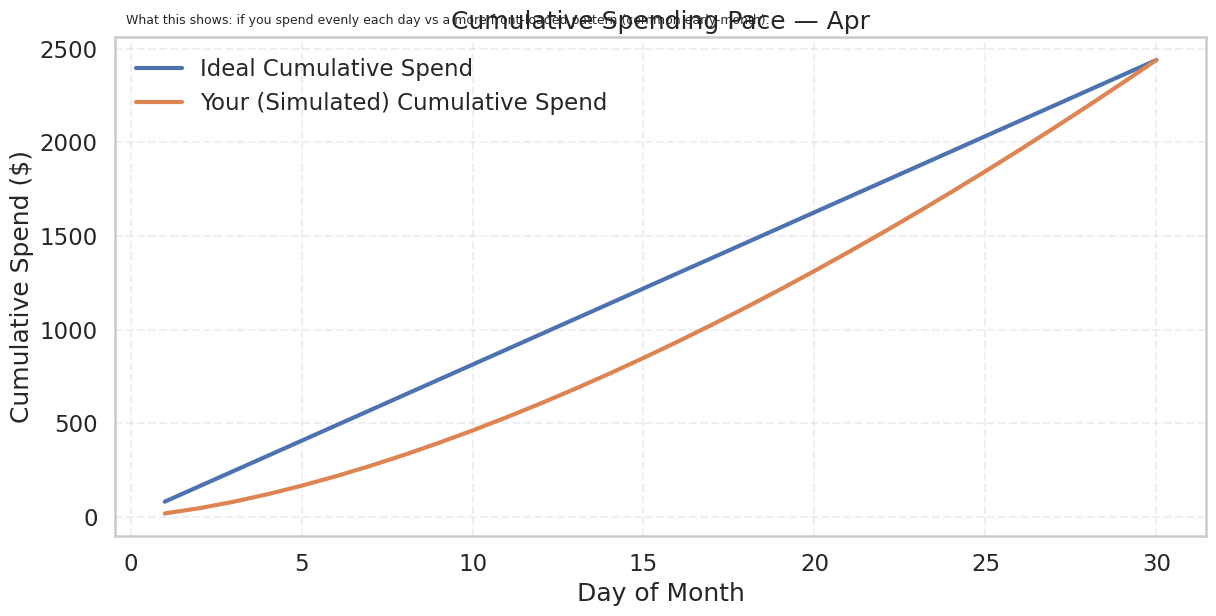

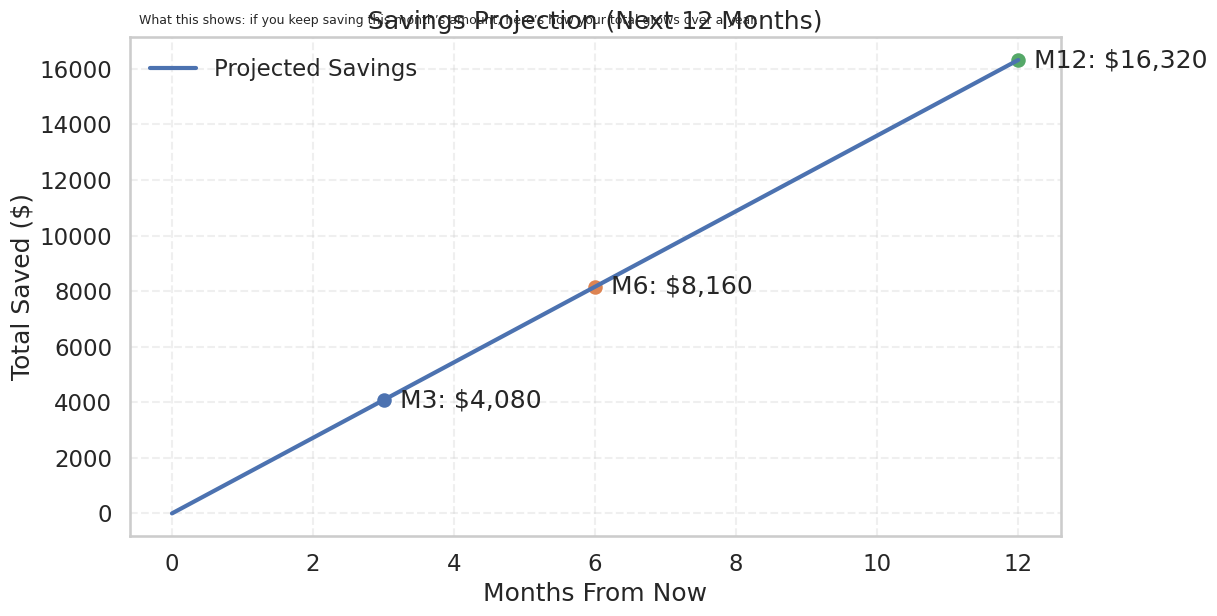

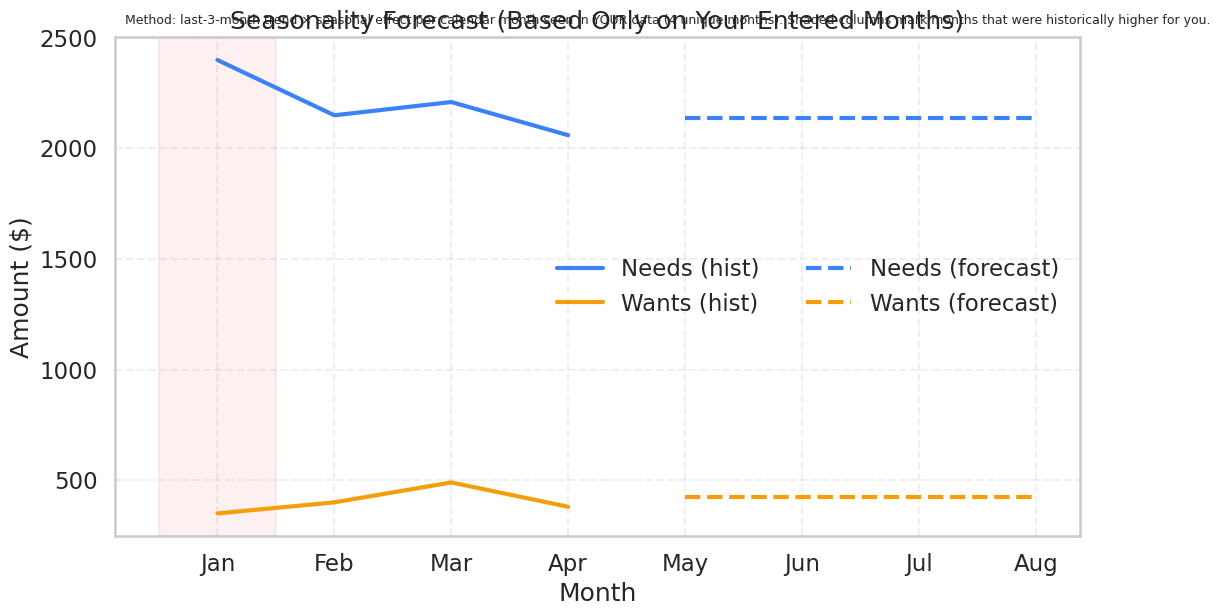


=== PERSONALIZED RECOMMENDATIONS ===
• Nice — your savings rate meets the 20% guideline. Maintain automatic transfers.
• Biggest discretionary drivers this month: Dining ($150), Personal ($100), Entertainment ($50).
• Groceries swings the most month-to-month — consider a hard limit or split into sub-budgets to tame spikes.
• Needs > 50%: shop insurance/utilities this month and aim for a cheaper plan at next renewal.


In [ ]:
# === VISUALS ADD-ON v3 (refined) — clear pie, readable/explanatory lines, user-data seasonality, personalized tips ===
# Drop this whole block in place of your previous VISUALS section.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def render_budget_visuals(
    all_months,
    months_names,
    needs_set,
    wants_set,
    recommended_rule,
    user_goal
):
    # Guard
    if len(all_months) == 0:
        print("\n[VISUALS] No months entered — skipping charts.")
        return

    # ---------- Helpers ----------
    def cat_group(c_name):
        if c_name in needs_set:
            return "Needs"
        elif c_name in wants_set:
            return "Wants"
        return "Wants"

    def end_label_line(ax, xvals, yvals, label, offset=0.01, color=None):
        """Annotate the last point of a line with its label/value."""
        if len(xvals) == 0:
            return
        x_last = xvals[-1]
        y_last = yvals[-1]
        txt = f"{label}: {y_last:,.0f}" if " %" not in label else f"{label}: {y_last:.0f}%"
        ax.text(x_last + 0.1, y_last * (1 + offset if y_last != 0 else 1) + (2 if " %" in label else 0),
                txt, va="center", fontsize=10, color=color)

    def percentile_cut(values, p=75):
        if len(values) == 0:
            return None
        return np.percentile(values, p)

    # ---------- Current month snapshot ----------
    curr = all_months[-1]
    month_label = curr["month_name"]
    monthly_income = float(curr["income"])
    needs_total = float(curr["needs_total"])
    wants_total = float(curr["wants_total"])
    savings_actual = float(curr["savings"])
    needs_pct = float(curr["needs_pct"])
    wants_pct = float(curr["wants_pct"])
    savings_pct = float(curr["savings_pct"])
    planned_expenses = curr["planned_expenses"]

    rec_needs = float(recommended_rule["Needs"])
    rec_wants = float(recommended_rule["Wants"])
    rec_sav   = float(recommended_rule["Savings"])

    # ---------- Tidy categories ----------
    cat_df = pd.DataFrame(
        [{"category": k, "amount": float(v)} for k, v in planned_expenses.items()]
    )
    if cat_df.empty:
        cat_df = pd.DataFrame([{"category": "(none)", "amount": 0.0}])
    cat_df["group"] = cat_df["category"].apply(cat_group)
    income_safe = monthly_income if monthly_income > 0 else 1.0
    cat_df["share_of_income"] = cat_df["amount"] / income_safe

    # ---------- 1) Donut pie: clearer labels + center summary ----------
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    actual_vals = np.array([needs_pct, wants_pct, savings_pct], dtype=float)
    base_vals   = np.array([rec_needs, rec_wants, rec_sav], dtype=float)
    if actual_vals.sum() == 0:
        actual_vals = np.array([0.0001, 0.0001, 0.0001], dtype=float)

    colors = ["#3b82f6", "#f59e0b", "#22c55e"]  # Needs, Wants, Savings
    labels_outer = [f"Needs ({needs_pct*100:.0f}%)",
                    f"Wants ({wants_pct*100:.0f}%)",
                    f"Savings ({savings_pct*100:.0f}%)"]
    labels_inner = ["50%", "30%", "20%"]

    wedges1, texts1, autotexts1 = ax.pie(
        actual_vals, radius=1.0, labels=labels_outer,
        labeldistance=1.08, colors=colors, startangle=90,
        autopct=lambda p: f"{p:.0f}%" if p >= 6 else "",
        pctdistance=0.75
    )
    wedges2, texts2 = ax.pie(
        base_vals, radius=0.68, labels=labels_inner,
        labeldistance=0.45, colors=colors, startangle=90,
        wedgeprops=dict(width=0.36, edgecolor="white")
    )
    centre_circle = plt.Circle((0, 0), 0.32, fc="white")
    ax.add_artist(centre_circle)

    # Center summary
    ax.text(0, 0.06, f"{month_label}", ha="center", va="center", fontsize=12, weight="bold")
    ax.text(0, -0.08, "Your mix vs 50/30/20", ha="center", va="center", fontsize=10)
    ax.set_title("Allocation Overview — Clear at a Glance", pad=16)
    plt.tight_layout()
    plt.show()

    # ---------- 2) MoM LINE CHARTS with readable guidance ----------
    mom_df = pd.DataFrame([{
        "Month": rec["month_name"],
        "Income": float(rec["income"]),
        "Needs": float(rec["needs_total"]),
        "Wants": float(rec["wants_total"]),
        "Savings": float(rec["savings"]),
        "Needs %": float(rec["needs_pct"]) * 100.0,
        "Wants %": float(rec["wants_pct"]) * 100.0,
        "Savings %": float(rec["savings_pct"]) * 100.0,
    } for rec in all_months])

    # Ensure order is the order user entered (already the case), but make an index for x-axis
    x = np.arange(len(mom_df))
    xlabels = mom_df["Month"].tolist()

    # (a) Amounts over time (line) + explanatory subtitle + end labels
    fig, ax = plt.subplots(figsize=(12.5, 6.5))
    ln1, = ax.plot(x, mom_df["Income"].values, linewidth=3, label="Income", color="#111827")
    ln2, = ax.plot(x, mom_df["Needs"].values, linewidth=3, label="Needs", color="#3b82f6")
    ln3, = ax.plot(x, mom_df["Wants"].values, linewidth=3, label="Wants", color="#f59e0b")
    ln4, = ax.plot(x, mom_df["Savings"].values, linewidth=3, label="Savings", color="#22c55e")

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_title("Month-over-Month: Dollars", pad=6)
    ax.set_xlabel("Month")
    ax.set_ylabel("Amount ($)")
    ax.grid(True, linestyle="--", alpha=0.3)

    # Reference lines for the current month amounts
    ax.axhline(needs_total,   color="#3b82f6", linestyle="--", linewidth=2, label=f"Current Needs (${needs_total:,.0f})")
    ax.axhline(wants_total,   color="#f59e0b", linestyle="--", linewidth=2, label=f"Current Wants (${wants_total:,.0f})")
    ax.axhline(savings_actual,color="#22c55e", linestyle="--", linewidth=2, label=f"Current Savings (${savings_actual:,.0f})")

    # End labels
    end_label_line(ax, x, mom_df["Income"].values,  "Income",  color="#111827")
    end_label_line(ax, x, mom_df["Needs"].values,   "Needs",   color="#3b82f6")
    end_label_line(ax, x, mom_df["Wants"].values,   "Wants",   color="#f59e0b")
    end_label_line(ax, x, mom_df["Savings"].values, "Savings", color="#22c55e")

    # Explanatory caption
    ax.text(0.01, 1.02,
            "What this shows: how your dollars move each month. Dotted lines mark your CURRENT month levels\n"
            "so you can quickly compare whether earlier months were above or below today’s plan.",
            transform=ax.transAxes, fontsize=9, va="bottom")

    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

    # (b) Percentages over time (line) + baseline + end labels + caption
    fig, ax = plt.subplots(figsize=(12.5, 6.5))
    ax.plot(x, mom_df["Needs %"].values,   linewidth=3, label="Needs %",   color="#3b82f6")
    ax.plot(x, mom_df["Wants %"].values,   linewidth=3, label="Wants %",   color="#f59e0b")
    ax.plot(x, mom_df["Savings %"].values, linewidth=3, label="Savings %", color="#22c55e")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_title("Month-over-Month: Allocation % of Income", pad=6)
    ax.set_xlabel("Month")
    ax.set_ylabel("Percent of Income (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle="--", alpha=0.3)

    # Baseline reference lines 50/30/20
    ax.axhline(rec_needs*100, color="#3b82f6", linestyle=":", linewidth=2, label="Needs baseline 50%")
    ax.axhline(rec_wants*100, color="#f59e0b", linestyle=":", linewidth=2, label="Wants baseline 30%")
    ax.axhline(rec_sav*100,   color="#22c55e", linestyle=":", linewidth=2, label="Savings baseline 20%")

    end_label_line(ax, x, mom_df["Needs %"].values,   "Needs %",   color="#3b82f6")
    end_label_line(ax, x, mom_df["Wants %"].values,   "Wants %",   color="#f59e0b")
    end_label_line(ax, x, mom_df["Savings %"].values, "Savings %", color="#22c55e")

    ax.text(0.01, 1.02,
            "What this shows: how your mix compares to the guideline. Dotted lines are the 50/30/20 targets.",
            transform=ax.transAxes, fontsize=9, va="bottom")
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

    # ---------- 3) Cumulative spend vs ideal pace (current month; simulated) ----------
    total_budget_to_spend = needs_total + wants_total
    month_length = 30
    days = np.arange(1, month_length + 1)
    ideal_daily = (total_budget_to_spend / month_length) if month_length > 0 else 0.0
    ideal_line  = ideal_daily * days

    # Simulate front-loaded spending curve
    front_load_factor = 1.8
    weights = np.array([(month_length - d + 1) for d in days])**(1 / front_load_factor)
    weights = weights[::-1]
    weights = weights / weights.sum()
    pseudo_spend = total_budget_to_spend * weights
    cumulative_pseudo = np.cumsum(pseudo_spend)

    fig, ax = plt.subplots(figsize=(12.5, 6.5))
    ax.plot(days, ideal_line,        linewidth=3, label="Ideal Cumulative Spend")
    ax.plot(days, cumulative_pseudo, linewidth=3, label="Your (Simulated) Cumulative Spend")
    ax.set_title(f"Cumulative Spending Pace — {month_label}", pad=6)
    ax.set_xlabel("Day of Month")
    ax.set_ylabel("Cumulative Spend ($)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.text(0.01, 1.02,
            "What this shows: if you spend evenly each day vs a more front-loaded pattern (common early-month).",
            transform=ax.transAxes, fontsize=9, va="bottom")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # ---------- 4) Savings projection (next 12 months) ----------
    goal_emergency_months = 3.0 if user_goal == "emergency" else 0.0
    target_emergency_total = goal_emergency_months * needs_total
    months_ahead = 12
    t = np.arange(0, months_ahead + 1)
    savings_monthly = max(savings_actual, 0.0)
    proj_savings = savings_monthly * t

    fig, ax = plt.subplots(figsize=(12.5, 6.5))
    ax.plot(t, proj_savings, linewidth=3, label="Projected Savings")
    if goal_emergency_months > 0:
        ax.axhline(target_emergency_total, linestyle="--", linewidth=2,
                   label=f"Emergency Goal (${target_emergency_total:,.0f})")
    ax.set_title("Savings Projection (Next 12 Months)", pad=6)
    ax.set_xlabel("Months From Now")
    ax.set_ylabel("Total Saved ($)")
    for i in [3, 6, 12]:
        if i <= months_ahead:
            ax.scatter([i], [proj_savings[i]], s=80)
            ax.text(i, proj_savings[i], f"  M{i}: ${proj_savings[i]:,.0f}", va="center")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.text(0.01, 1.02,
            "What this shows: if you keep saving this month’s amount, here’s how your total grows over a year.",
            transform=ax.transAxes, fontsize=9, va="bottom")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # ---------- 5) Seasonality-aware forecast (based ONLY on user's entered months) ----------
    if len(all_months) >= 2:
        # Build historical series in the order the user entered
        hist_df = pd.DataFrame([{
            "MonthIdx":   rec["month_index"],
            "MonthName":  rec["month_name"],
            "Needs":      float(rec["needs_total"]),
            "Wants":      float(rec["wants_total"]),
            "Savings":    float(rec["savings"]),
            "TotalSpend": float(rec["needs_total"]) + float(rec["wants_total"]),
        } for rec in all_months])

        # Seasonal indices by observed calendar month only
        observed_months = sorted(hist_df["MonthIdx"].unique().tolist())
        overall  = hist_df["TotalSpend"].mean() if len(hist_df) else 1.0
        if overall == 0:
            overall = 1.0
        seasonal_means = hist_df.groupby("MonthIdx")["TotalSpend"].mean()
        seasonal_index = (seasonal_means / overall).to_dict()

        # Trend: last 3-point moving average on observed TotalSpend (in input order)
        roll = hist_df["TotalSpend"].rolling(window=3, min_periods=1).mean()
        last_trend = float(roll.iloc[-1]) if len(roll) else (needs_total + wants_total)

        # Forecast next N months (N=min(6, number of distinct observed months))
        steps = min(6, max(1, len(observed_months)))
        start_month_idx = (curr["month_index"] + 1) % 12
        fc_months_idx   = [(start_month_idx + i) % 12 for i in range(steps)]
        fc_months_name  = [months_names[i] for i in fc_months_idx]

        # Use seasonal factors ONLY if that calendar month was observed; else neutral (1.0)
        base_level = last_trend if last_trend > 0 else (needs_total + wants_total)
        forecast_spend = [base_level * seasonal_index.get(mi, 1.0) for mi in fc_months_idx]

        # Split forecast across Needs/Wants using recent proportions (last up to 3 data points)
        if len(hist_df) >= 3 and hist_df["TotalSpend"].iloc[-3:].sum() > 0:
            recent_needs_share = hist_df["Needs"].iloc[-3:].sum() / hist_df["TotalSpend"].iloc[-3:].sum()
        else:
            denom = needs_total + wants_total
            recent_needs_share = (needs_total / denom) if denom > 0 else 0.5
        recent_wants_share = 1.0 - recent_needs_share

        fc_needs = [v * recent_needs_share for v in forecast_spend]
        fc_wants = [v * recent_wants_share for v in forecast_spend]

        # Determine "peak months" from user history (>=75th percentile of TotalSpend by observed month)
        month_to_mean = seasonal_means.to_dict()
        threshold = percentile_cut(list(month_to_mean.values()), 75) or 0
        observed_peak_names = [months_names[k] for k, v in month_to_mean.items() if v >= threshold and v > 0]

        fig, ax = plt.subplots(figsize=(12.5, 6.5))
        # Historical lines (input order)
        ax.plot(hist_df["MonthName"], hist_df["Needs"], linewidth=3, label="Needs (hist)", color="#3b82f6")
        ax.plot(hist_df["MonthName"], hist_df["Wants"], linewidth=3, label="Wants (hist)", color="#f59e0b")
        # Forecast (dashed)
        ax.plot(fc_months_name, fc_needs, linewidth=3, linestyle="--", label="Needs (forecast)", color="#3b82f6")
        ax.plot(fc_months_name, fc_wants, linewidth=3, linestyle="--", label="Wants (forecast)", color="#f59e0b")

        # Soft-highlight months that YOUR history flagged as peaks
        xlabels_all = list(hist_df["MonthName"]) + fc_months_name
        for i, name in enumerate(xlabels_all):
            if name in observed_peak_names:
                ax.axvspan(i-0.5, i+0.5, alpha=0.08, color="#ef4444")

        ax.set_title("Seasonality Forecast (Based Only on Your Entered Months)", pad=6)
        ax.set_xlabel("Month")
        ax.set_ylabel("Amount ($)")
        ax.grid(True, linestyle="--", alpha=0.3)
        # Caption explaining method
        ax.text(0.01, 1.02,
                f"Method: last-3-month trend × seasonal effect per calendar month seen in YOUR data ({len(observed_months)} unique months). "
                f"Shaded columns mark months that were historically higher for you.",
                transform=ax.transAxes, fontsize=9, va="bottom")
        ax.legend(frameon=False, ncol=2)
        plt.tight_layout()
        plt.show()

    # ---------- 6) Personalized recommendations (based on your patterns) ----------
    print("\n=== PERSONALIZED RECOMMENDATIONS ===")
    # Savings target gap
    target_savings_pct = rec_sav
    if savings_pct < target_savings_pct:
        gap = (target_savings_pct - savings_pct) * monthly_income
        print(f"• To hit a {int(target_savings_pct*100)}% savings rate, move ≈ ${gap:,.0f}/mo from Wants to Savings.")
    else:
        print(f"• Nice — your savings rate meets the {int(target_savings_pct*100)}% guideline. Maintain automatic transfers.")

    # Wants hot-spots (top 3)
    wants_top = (cat_df[cat_df["group"] == "Wants"]
                 .sort_values("amount", ascending=False)
                 .head(3)[["category","amount"]].values.tolist())
    if wants_top:
        msg = "• Biggest discretionary drivers this month: " + ", ".join([f"{c} (${a:,.0f})" for c, a in wants_top]) + "."
        print(msg)

    # Trend checks on last 3 entries (if available)
    if len(all_months) >= 3:
        last3 = mom_df.iloc[-3:]
        # Wants rising?
        if last3["Wants"].is_monotonic_increasing and last3["Savings"].iloc[-1] < last3["Savings"].iloc[0]:
            print("• Wants are rising over the last 3 months while Savings slipped — set a fixed weekly cap for Dining/Entertainment.")
        # Income dip?
        if last3["Income"].iloc[-1] < last3["Income"].iloc[0]:
            print("• Income dipped recently — pause new subscriptions and renegotiate bills until income stabilizes.")

    # Category volatility (identify one category with high variance if multiple months exist)
    if len(all_months) >= 2:
        # Build history by category if keys are consistent across months
        cat_hist = {}
        for rec in all_months:
            for k, v in rec["planned_expenses"].items():
                cat_hist.setdefault(k, []).append(float(v))
        vol = []
        for k, arr in cat_hist.items():
            if len(arr) >= 2:
                vol.append((k, np.std(arr)))
        if vol:
            vol.sort(key=lambda x: x[1], reverse=True)
            k, s = vol[0]
            print(f"• {k} swings the most month-to-month — consider a hard limit or split into sub-budgets to tame spikes.")

    # Emergency fund nudges
    if user_goal == "emergency":
        target_emergency_total = 3.0 * needs_total
        savings_monthly = max(savings_actual, 0.0)
        months_to_goal = int(np.ceil(max(0.0, target_emergency_total) / max(1.0, savings_monthly)))
        print(f"• Emergency fund goal ≈ ${target_emergency_total:,.0f}. At ${savings_monthly:,.0f}/mo you’re ~{months_to_goal} months away. Add an extra $50–$100/mo to close faster.")

    # Quick habit tips based on mix
    if wants_pct > rec_wants:
        print("• Wants > 30%: try a “two-out, one-in” rule for subscriptions and set a Dining envelope that resets weekly.")
    if needs_pct > rec_needs:
        print("• Needs > 50%: shop insurance/utilities this month and aim for a cheaper plan at next renewal.")

# ====== Single clean call (keeps backend hidden; users just see visuals/guidance) ======
render_budget_visuals(all_months, months_names, needs_set, wants_set, recommended_rule, user_goal)



📊 Welcome to the Budget Planner CLI!

What is your main financial goal (travel, debt, emergency, savings)? travel
🎯 Your goal is set to: travel


--- Jan ---
Enter income for Jan: 4000
Enter your planned expenses (leave blank = 0):
  Housing: 1600
  Utilities: 300
  Groceries: 200
  Dining: 300
  Transportation: 100
  Insurance: 500
  Debt Payments: 200
  Health: 100
  Entertainment: 300
  Subscriptions: 300
  Personal: 400
  Education: 100
  Gifts/Charity: 200
  Misc: 400

✅ Jan Summary:
Income: $4000.00
Needs: $3000.00 (75.0%)
Wants: $2000.00 (50.0%)
Savings: $0.00 (0.0%)

💡 Personalized Recommendations:
Try to increase your savings to at least 20% for travel plans.


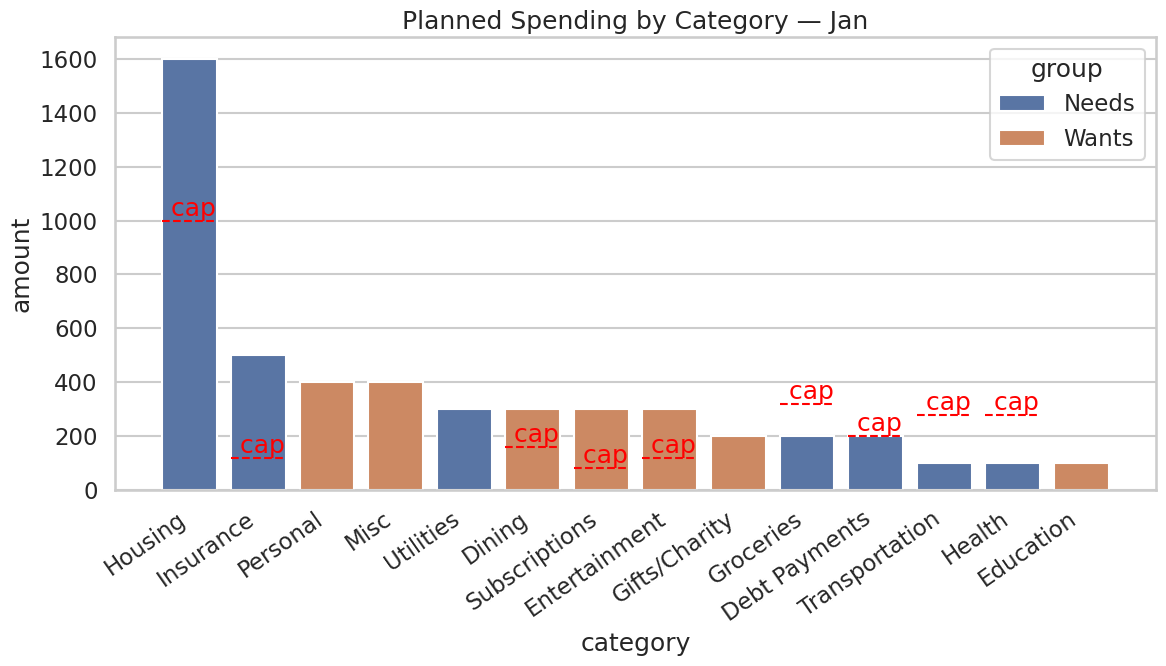

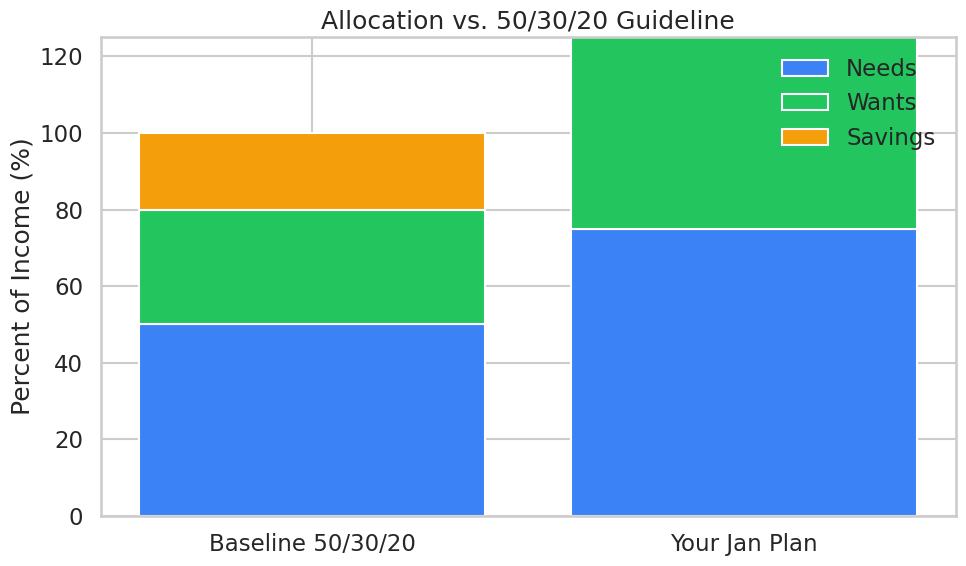


Do you want to enter next month? (y/n): y

--- Feb ---
Enter income for Feb: 4000
Enter your planned expenses (leave blank = 0):
  Housing: 1600
  Utilities: 100
  Groceries: 150
  Dining: 80
  Transportation: 80
  Insurance: 100
  Debt Payments: 0
  Health: 0
  Entertainment: 50
  Subscriptions: 80
  Personal: 50
  Education: 100
  Gifts/Charity: 0
  Misc: 0

✅ Feb Summary:
Income: $4000.00
Needs: $2030.00 (50.7%)
Wants: $360.00 (9.0%)
Savings: $1610.00 (40.2%)

💡 Personalized Recommendations:
Great! You're saving enough for travel 🎒


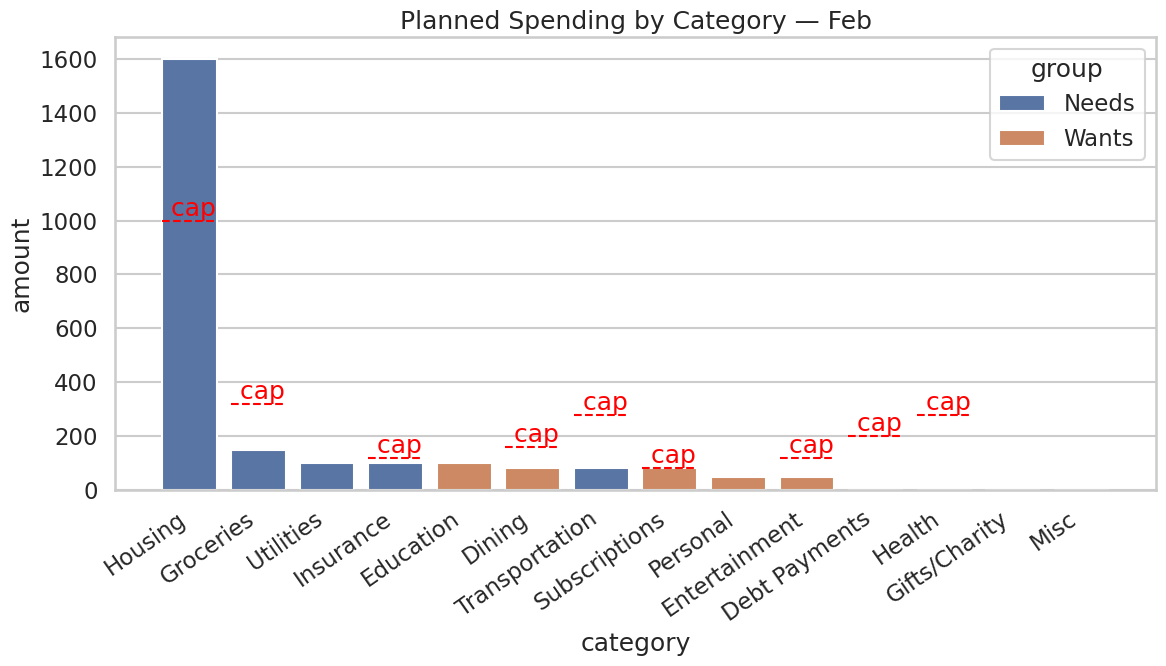

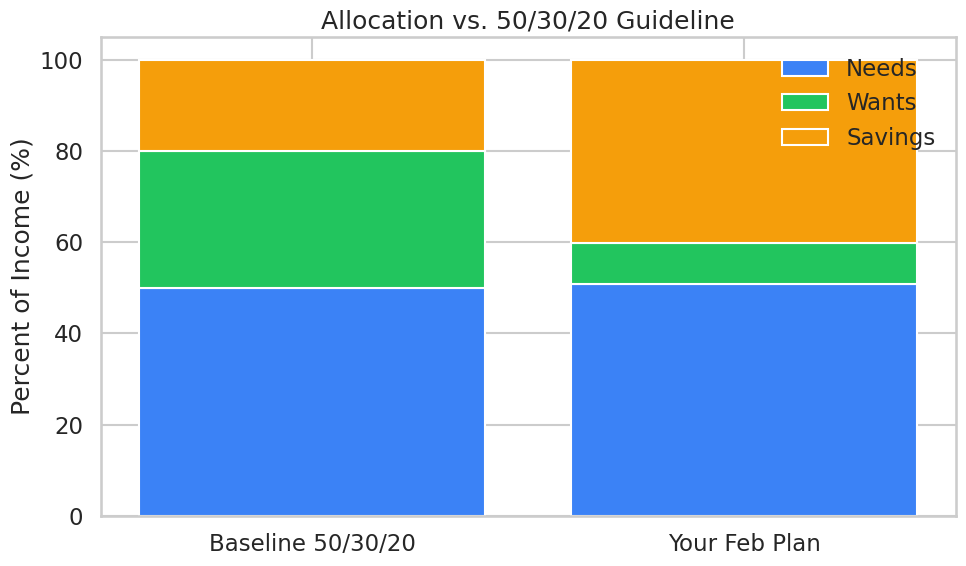

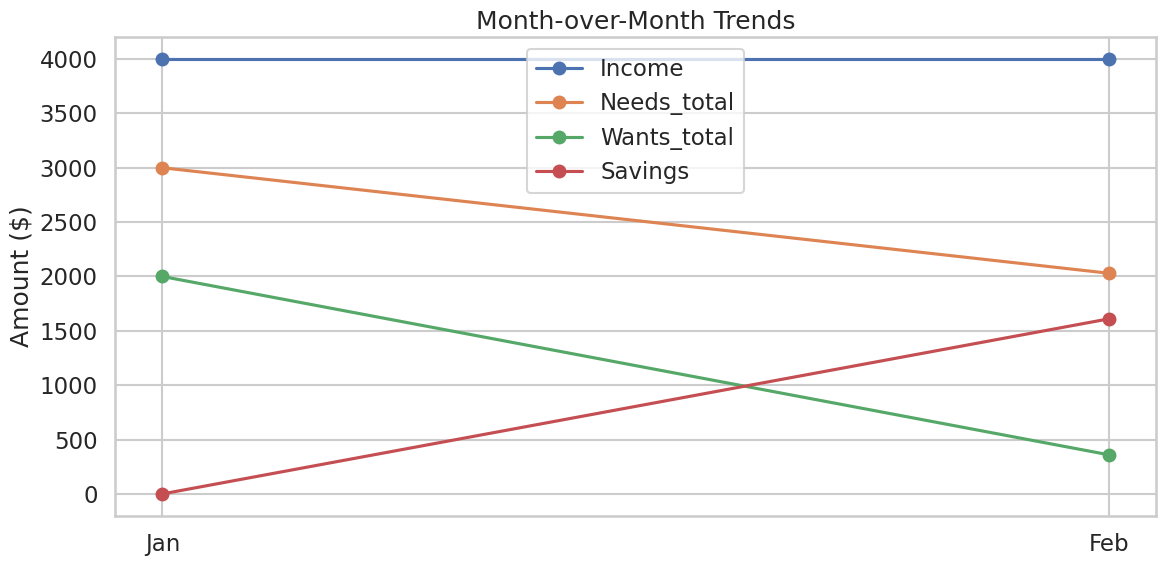


Do you want to enter next month? (y/n): y

--- Mar ---
Enter income for Mar: 4000
Enter your planned expenses (leave blank = 0):
  Housing: 1600
  Utilities: 100
  Groceries: 150
  Dining: 100
  Transportation: 80
  Insurance: 60
  Debt Payments: 0
  Health: 0
  Entertainment: 50
  Subscriptions: 50
  Personal: 0
  Education: 100
  Gifts/Charity: 0
  Misc: 0

✅ Mar Summary:
Income: $4000.00
Needs: $1990.00 (49.8%)
Wants: $300.00 (7.5%)
Savings: $1710.00 (42.8%)

💡 Personalized Recommendations:
Great! You're saving enough for travel 🎒


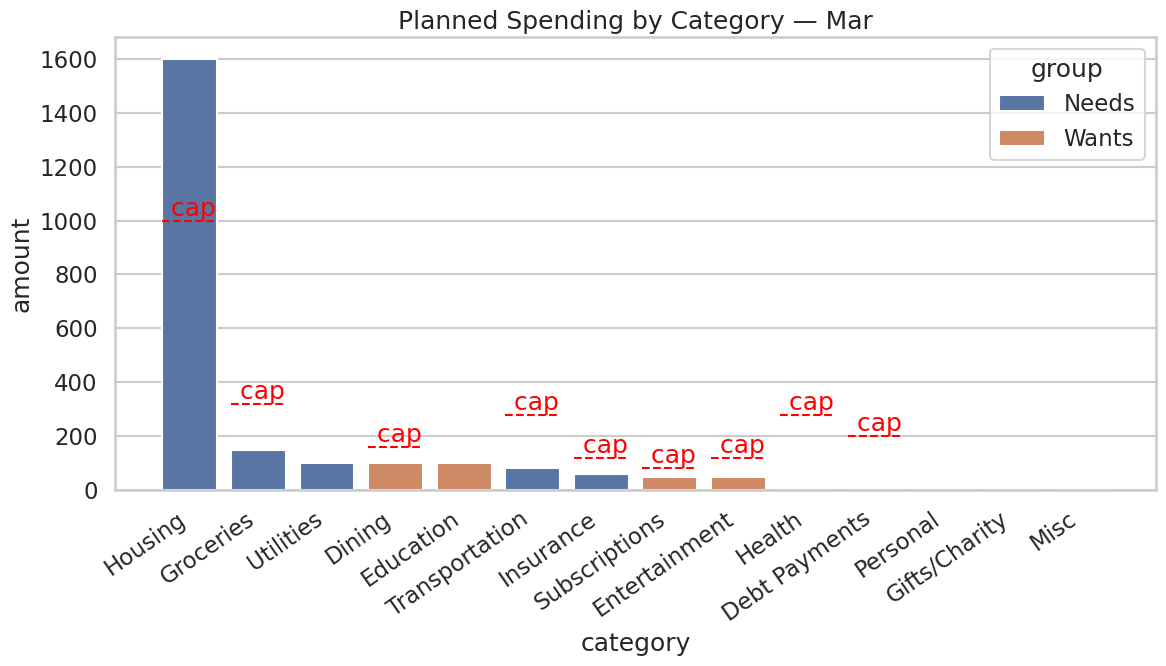

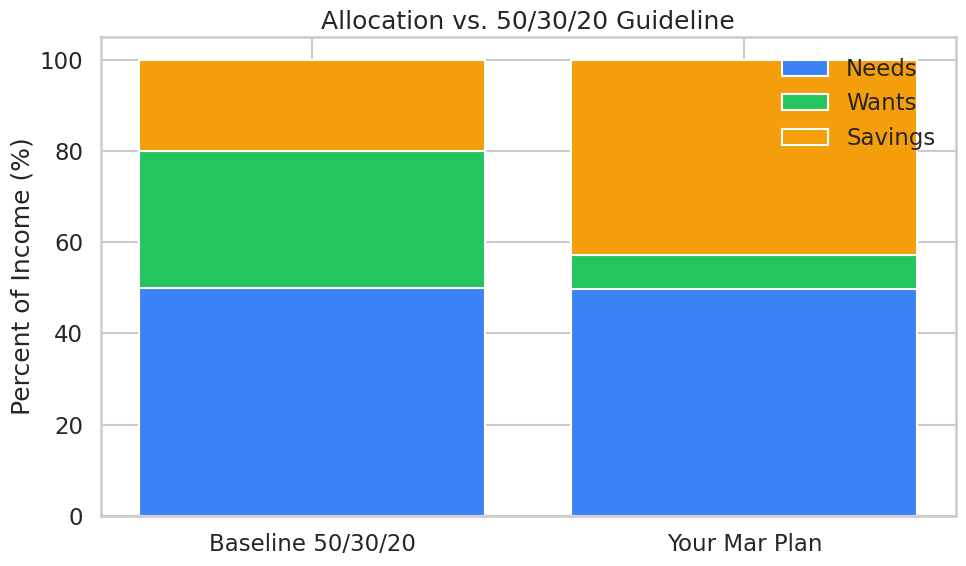

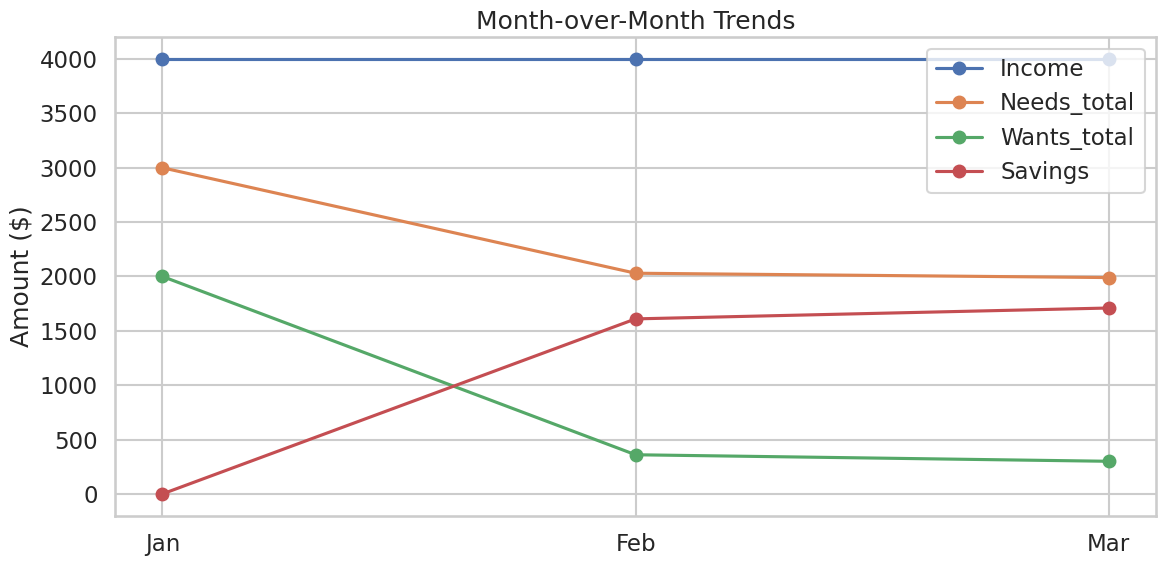


Do you want to enter next month? (y/n): n

📈 Final Projections:


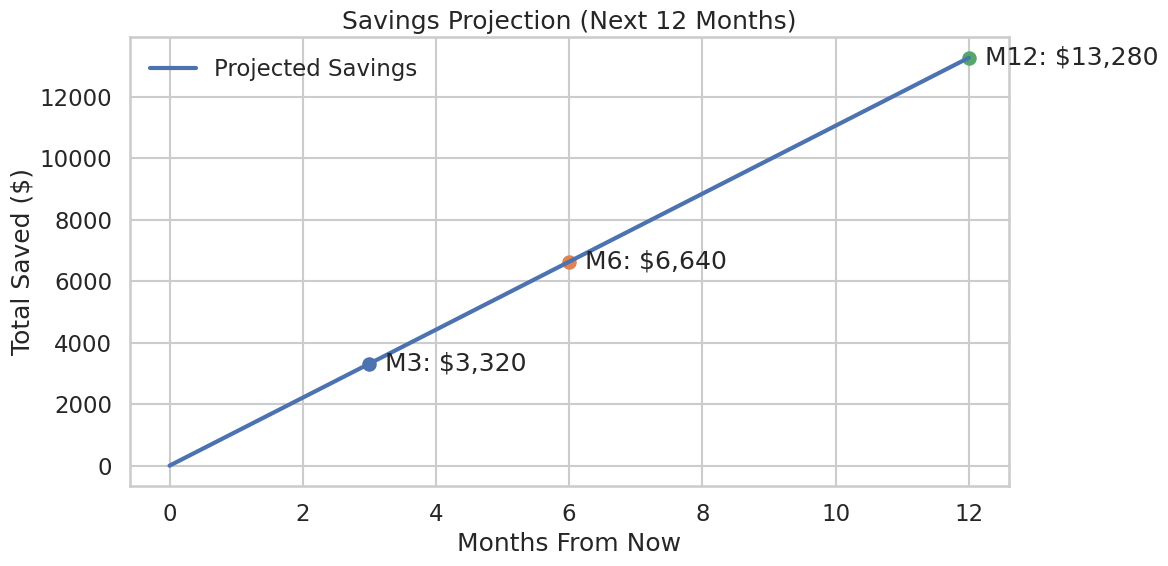

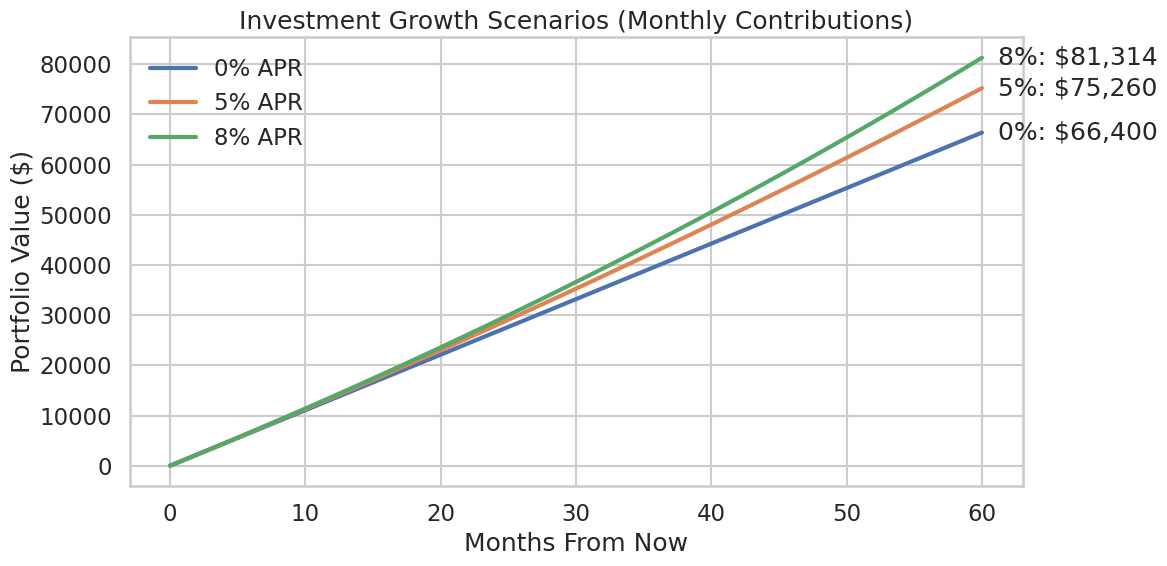


📊 Overall Budget Flow:



👋 Exiting Budget Planner. Goodbye!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go


sns.set_theme(style="whitegrid", context="talk")


class BudgetMonth:
    def __init__(self, month_index, month_name, income, planned_expenses,
                 needs_set, wants_set, recommended_rule):
        self.month_index = month_index
        self.month_name = month_name
        self.income = income
        self.planned_expenses = planned_expenses
        self.needs_set = needs_set
        self.wants_set = wants_set
        self.recommended_rule = recommended_rule

        self.needs_total, self.wants_total = self._aggregate_expenses()
        self.savings = max(0, self.income - sum(planned_expenses.values()))
        self.needs_pct, self.wants_pct, self.savings_pct = self._calculate_ratios()

    def _aggregate_expenses(self):
        needs_total, wants_total = 0, 0
        for cat, val in self.planned_expenses.items():
            if cat in self.needs_set:
                needs_total += val
            else:  # default to wants if not in needs_set
                wants_total += val
        return needs_total, wants_total

    def _calculate_ratios(self):
        denom = self.income if self.income > 0 else 1
        return (self.needs_total / denom,
                self.wants_total / denom,
                self.savings / denom)

    def summary(self):
        return {
            "month_index": self.month_index,
            "month_name": self.month_name,
            "income": self.income,
            "needs_total": self.needs_total,
            "wants_total": self.wants_total,
            "savings": self.savings,
            "needs_pct": self.needs_pct,
            "wants_pct": self.wants_pct,
            "savings_pct": self.savings_pct,
            "planned_expenses": self.planned_expenses,
        }


class BudgetApp:
    def __init__(self, months_names, spending_categories, needs_set, wants_set, recommended_rule):
        self.months_names = months_names
        self.spending_categories = spending_categories
        self.needs_set = needs_set
        self.wants_set = wants_set
        self.recommended_rule = recommended_rule
        self.all_months = []

    def add_month(self, month_index, income, planned_expenses):
        month = BudgetMonth(
            month_index, self.months_names[month_index], income,
            planned_expenses, self.needs_set, self.wants_set, self.recommended_rule
        )
        self.all_months.append(month)
        return month

    def get_all_summaries(self):
        return [m.summary() for m in self.all_months]


class BudgetVisualizer:
    def __init__(self, all_months, recommended_rule, needs_set, wants_set, user_goal="savings"):
        self.all_months = all_months
        self.recommended_rule = recommended_rule
        self.needs_set = needs_set
        self.wants_set = wants_set
        self.user_goal = user_goal

    def _cat_group(self, category):
        if category in self.needs_set:
            return "Needs"
        elif category in self.wants_set:
            return "Wants"
        return "Wants"

    def print_goal_recommendations(self, month):
        print("\n💡 Personalized Recommendations:")

        if self.user_goal == "travel":
            if month.savings_pct >= 0.2:
                print("Great! You're saving enough for travel 🎒")
            else:
                print("Try to increase your savings to at least 20% for travel plans.")
        elif self.user_goal == "debt":
            debt_expense = month.planned_expenses.get("Debt Payments", 0)
            if debt_expense > 0:
                print("👍 You're putting money toward debt repayment.")
            else:
                print("Consider allocating money to debt reduction this month.")
        elif self.user_goal == "emergency":
            if month.savings_pct >= 0.15:
                print("✅ You're building a solid emergency fund.")
            else:
                print("Aim to save at least 15% for emergencies.")
        elif self.user_goal == "savings":
            if month.savings_pct >= self.recommended_rule["Savings"]:
                print("💰 You're meeting the 20% savings rule.")
            else:
                print("Try to save closer to 20% of your income.")

    def plot_category_bars(self, month):
        df = pd.DataFrame([
            {"category": k, "amount": v, "group": self._cat_group(k)}
            for k, v in month.planned_expenses.items()
        ])

        # Adjusted caps for optimized savings (stricter than before)
        caps = {
            # Needs (≤50%)
            "Housing": 0.25,        # Biggest expense but capped lower than 28%
            "Groceries": 0.08,
            "Transportation": 0.07,
            "Insurance": 0.03,
            "Health": 0.07,
            "Debt Payments": 0.05,

            # Wants (≤20%)
            "Dining": 0.04,
            "Entertainment": 0.03,
            "Subscriptions": 0.02
        }

        order = df.sort_values("amount", ascending=False)["category"]
        plt.figure(figsize=(12, 7))
        ax = sns.barplot(data=df, x="category", y="amount", hue="group", order=order)

        # Add cap lines
        for idx, cat in enumerate(order):
            if cat in caps:
                cap_value = month.income * caps[cat]
                ax.hlines(y=cap_value, xmin=idx-0.4, xmax=idx+0.4,
                          colors="red", linestyles="--", linewidth=1.5)
                ax.text(idx, cap_value, " cap", color="red", ha="center", va="bottom")

        ax.set_title(f"Planned Spending by Category — {month.month_name}")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_allocation_comparison(self, month):
        baseline = pd.DataFrame({
            "label": ["Baseline 50/30/20"],
            "Needs": [self.recommended_rule["Needs"]],
            "Wants": [self.recommended_rule["Wants"]],
            "Savings": [self.recommended_rule["Savings"]],
        })
        actual = pd.DataFrame({
            "label": [f"Your {month.month_name} Plan"],
            "Needs": [month.needs_pct],
            "Wants": [month.wants_pct],
            "Savings": [month.savings_pct],
        })
        compare = pd.concat([baseline, actual])

        plt.figure(figsize=(10, 6))
        bottom = np.zeros(len(compare))
        colors = {"Needs": "#3b82f6", "Wants": "#22c55e", "Savings": "#f59e0b"}
        for col in ["Needs", "Wants", "Savings"]:
            vals = compare[col].values * 100
            plt.bar(compare["label"], vals, bottom=bottom * 100, label=col, color=colors[col])
            bottom += compare[col].values
        plt.title("Allocation vs. 50/30/20 Guideline")
        plt.ylabel("Percent of Income (%)")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    def plot_mom_trends(self):
        if len(self.all_months) < 2:
            return
        df = pd.DataFrame([m.summary() for m in self.all_months])
        plt.figure(figsize=(12, 6))
        for col in ["income", "needs_total", "wants_total", "savings"]:
            plt.plot(df["month_name"], df[col], marker="o", label=col.capitalize())
        plt.title("Month-over-Month Trends")
        plt.ylabel("Amount ($)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_savings_trajectory(self):
        if not self.all_months:
            return

        avg_savings = np.mean([m.savings for m in self.all_months])
        avg_needs = np.mean([m.needs_total for m in self.all_months])

        # Emergency target = 3 months of needs if goal is "emergency"
        goal_emergency_months = 3 if self.user_goal == "emergency" else 0
        target_emergency_total = goal_emergency_months * avg_needs

        months_ahead = 12
        t = np.arange(0, months_ahead + 1)
        proj_savings = avg_savings * t

        plt.figure(figsize=(12, 6))
        plt.plot(t, proj_savings, linewidth=3, label="Projected Savings")
        if goal_emergency_months > 0:
            plt.axhline(target_emergency_total, linestyle="--", linewidth=2,
                        label=f"Emergency Goal (${target_emergency_total:,.0f})")
        plt.title("Savings Projection (Next 12 Months)")
        plt.xlabel("Months From Now")
        plt.ylabel("Total Saved ($)")
        for i in [3, 6, 12]:
            if i <= months_ahead:
                plt.scatter([i], [proj_savings[i]], s=80)
                plt.text(i, proj_savings[i], f"  M{i}: ${proj_savings[i]:,.0f}", va="center")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    def plot_investment_growth(self):
        if not self.all_months:
            return

        avg_savings = np.mean([m.savings for m in self.all_months])

        def future_values(months, contrib, apr):
            r = apr / 12.0
            values = []
            total = 0.0
            for _ in range(months + 1):
                values.append(total)
                total = total * (1 + r) + contrib
            return np.array(values)

        horizon = 60  # 5 years
        fv_0 = future_values(horizon, avg_savings, 0.00)
        fv_5 = future_values(horizon, avg_savings, 0.05)
        fv_8 = future_values(horizon, avg_savings, 0.08)

        plt.figure(figsize=(12, 6))
        xh = np.arange(horizon + 1)
        plt.plot(xh, fv_0, linewidth=3, label="0% APR")
        plt.plot(xh, fv_5, linewidth=3, label="5% APR")
        plt.plot(xh, fv_8, linewidth=3, label="8% APR")
        plt.title("Investment Growth Scenarios (Monthly Contributions)")
        plt.xlabel("Months From Now")
        plt.ylabel("Portfolio Value ($)")
        for label, val in [("0%", fv_0[-1]), ("5%", fv_5[-1]), ("8%", fv_8[-1])]:
            plt.text(horizon, val, f"  {label}: ${val:,.0f}", va="center")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()


    def plot_sankey_overall(self):
      if not self.all_months:
          print("No months entered yet.")
          return

      # Aggregate totals
      total_income = sum(m.income for m in self.all_months)
      total_needs = sum(m.needs_total for m in self.all_months)
      total_wants = sum(m.wants_total for m in self.all_months)
      total_savings = sum(m.savings for m in self.all_months)

      # Sum subcategories
      subcat_totals = {}
      for m in self.all_months:
          for cat, val in m.planned_expenses.items():
              subcat_totals[cat] = subcat_totals.get(cat, 0) + val

      # Create a dummy node for Savings middle section
      savings_dummy = "Savings (middle)"

      # Nodes
      income_node = "Income"
      main_categories = ["Needs", "Wants", savings_dummy]  # Savings middle node
      subcategories = list(subcat_totals.keys())
      labels = [income_node] + main_categories + subcategories
      node_indices = {label: i for i, label in enumerate(labels)}

      # Links: Income → Main categories
      sources_income_to_main = [node_indices[income_node]] * 3
      targets_income_to_main = [node_indices["Needs"], node_indices["Wants"], node_indices[savings_dummy]]
      values_income_to_main = [total_needs, total_wants, total_savings]

      # Links: Main categories → Subcategories
      sources_main_to_sub = []
      targets_main_to_sub = []
      values_main_to_sub = []

      # Color mapping for main categories
      main_colors = {"Needs": "#636EFA", "Wants": "#00CC96", savings_dummy: "#FFA15A"}
      sub_colors = []

      for cat, amount in subcat_totals.items():
          if cat in self.needs_set:
              parent = "Needs"
          elif cat in self.wants_set:
              parent = "Wants"
          else:
              parent = savings_dummy

          sources_main_to_sub.append(node_indices[parent])
          targets_main_to_sub.append(node_indices[cat])
          values_main_to_sub.append(amount)
          sub_colors.append(main_colors[parent])

      # Combine links
      sources = sources_income_to_main + sources_main_to_sub
      targets = targets_income_to_main + targets_main_to_sub
      values = values_income_to_main + values_main_to_sub

      # Node colors
      node_colors = ["#AAAAAA"] + [main_colors[c] for c in main_categories] + sub_colors  # Income gray

      # Node labels with amounts
      node_values = [total_income, total_needs, total_wants, total_savings] + [subcat_totals[c] for c in subcategories]
      # Adjust label for savings dummy
      node_labels_with_values = [income_node,
                                f"Needs\n${total_needs:,.0f}",
                                f"Wants\n${total_wants:,.0f}",
                                f"Savings\n${total_savings:,.0f}"] + \
                                [f"{c}\n${subcat_totals[c]:,.0f}" for c in subcategories]

      # Sankey plot
      fig = go.Figure(data=[go.Sankey(
          node=dict(
              pad=15,
              thickness=20,
              line=dict(color="black", width=0.5),
              label=node_labels_with_values,
              color=node_colors
          ),
          link=dict(
              source=sources,
              target=targets,
              value=values,
              hovertemplate='%{source.label} → %{target.label}<br>Amount: $%{value:,.0f}<extra></extra>'
          )
      )])

      fig.update_layout(title_text="Sankey Diagram — Total Budget Flow", font_size=12)
      fig.show()


class BudgetCLI:
    def __init__(self, app, visualizer):
        self.app = app
        self.visualizer = visualizer

    def _get_float(self, prompt):
        while True:
            val = input(prompt).strip()
            if val == "":
                return 0.0
            try:
                val = float(val)
                if val < 0:
                    print("Please enter a non-negative number.")
                else:
                    return val
            except ValueError:
                print("Invalid input. Please enter a number.")

    def run(self):
        print("📊 Welcome to the Budget Planner CLI!\n")
        goal = input("What is your main financial goal "
                     "(travel, debt, emergency, savings)? ").strip().lower()
        if goal not in ["travel", "debt", "emergency", "savings"]:
            goal = "savings"
        self.visualizer.user_goal = goal
        print(f"🎯 Your goal is set to: {goal}\n")

        for i, month_name in enumerate(self.app.months_names):
            print(f"\n--- {month_name} ---")
            income = self._get_float(f"Enter income for {month_name}: ")

            planned_expenses = {}
            print("Enter your planned expenses (leave blank = 0):")
            for cat in self.app.spending_categories:
                planned_expenses[cat] = self._get_float(f"  {cat}: ")

            month = self.app.add_month(i, income, planned_expenses)

            summary = month.summary()
            print(f"\n✅ {month_name} Summary:")
            print(f"Income: ${summary['income']:.2f}")
            print(f"Needs: ${summary['needs_total']:.2f} "
                  f"({summary['needs_pct']*100:.1f}%)")
            print(f"Wants: ${summary['wants_total']:.2f} "
                  f"({summary['wants_pct']*100:.1f}%)")
            print(f"Savings: ${summary['savings']:.2f} "
                  f"({summary['savings_pct']*100:.1f}%)")

            self.visualizer.print_goal_recommendations(month)
            self.visualizer.plot_category_bars(month)
            self.visualizer.plot_allocation_comparison(month)
            self.visualizer.plot_mom_trends()

            cont = input("\nDo you want to enter next month? (y/n): ").strip().lower()
            if cont != "y":
                print("\n📈 Final Projections:")
                self.visualizer.plot_savings_trajectory()
                self.visualizer.plot_investment_growth()
                print("\n📊 Overall Budget Flow:")
                self.visualizer.plot_sankey_overall()
                print("\n👋 Exiting Budget Planner. Goodbye!")
                break


# ======================
# Example usage
# ======================
if __name__ == "__main__":
    months_names = ("Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec")
    spending_categories = [
        "Housing", "Utilities", "Groceries", "Dining", "Transportation",
        "Insurance", "Debt Payments", "Health", "Entertainment",
        "Subscriptions", "Personal", "Education", "Gifts/Charity", "Misc"
    ]
    needs_set = {"Housing","Utilities","Groceries","Transportation","Insurance","Debt Payments","Health"}
    wants_set = {"Dining","Entertainment","Subscriptions","Personal","Education","Gifts/Charity","Misc"}
    recommended_rule = {"Needs": 0.50, "Wants": 0.30, "Savings": 0.20}

    app = BudgetApp(months_names, spending_categories, needs_set, wants_set, recommended_rule)
    viz = BudgetVisualizer(app.all_months, recommended_rule, needs_set, wants_set, user_goal="savings")

    cli = BudgetCLI(app, viz)
    cli.run()